# 🎯 Meningioma Thresholder

Run from the **repo root** (`meningioma-atypier/`). Consumes `output/datasets/` from the cleaning notebook — the same handoff the modelling notebook uses — and writes everything it produces to its own folder, **`output/thresholds/`**.

## What this notebook answers

Two questions, and they are **not the same question**:

1. **Where does the risk of high-grade meningioma climb most steeply?** (§04)
   The *"šķēre"*. This is a question about the shape of a risk curve — at what tumor volume, or what ADC, does the probability of WHO 2–3 start rising fast? It is answered by fitting the risk, not by splitting the cohort.
2. **Do several cut-points used together beat the best single one?** (§06)
   Answered by fixing each cut-point first, then scoring every AND / OR / count-based combination against three benchmarks.

Question 1 is often confused with "what is the optimal cut-point", which is a third question (§05) with a different answer. A metric can have a perfectly good Youden cut-point and no threshold effect anywhere — Youden's *J* asks which split separates the grades best, and knows nothing about the shape of the risk in between.

## Metrics

**ADC** (mean, ×10⁻³ mm²/s) · **tumor volume** (cc) · **peritumoral edema volume** (cc) · **edema index** (edema ÷ tumor volume).

## Where the code lives

The statistics are in `heavy_machinery/threshold_phase/`, unit-tested alongside the rest of the pipeline (`pytests_atypier/test_thresholds.py`, `test_risk_curves.py`, `test_combinations.py`, `test_threshold_stability.py`). This notebook is configuration, narrative, and figures.

⚠️ **Nothing here is ever written back into the cleaning handoff.** A cut-point estimated on this cohort has already seen the outcome column; feeding it into the imputation or the multivariable models would leak the answer into the predictors. The published cut-points already in cleaning (`edema_volume_ge3.64`, `tumor_volume_ge13.95`) are a different case — they came from other people's patients.

<details>
<summary><b>Notebook map</b></summary>

| Step | What it does | Output folder |
|------|--------------|---------------|
| 00 | Setup — imports, run settings, `output/thresholds/` sink | — |
| 01 | Load the unimputed cohort from the handoff | — |
| 02 | Outcome, metric definitions, analysable sample per metric | tables |
| 03 | Distributions by grade — is there any separation to work with? | figures |
| **04** | **Risk curves — the "šķēre"** | figures + tables |
| 05 | Single cut-points — ROC table, five selection rules, bootstrap | figures + tables |
| **06** | **Combinations — do two cut-points beat one?** | figures + tables |
| 07 | Stability across the m MICE draws (all three analyses) | figures + tables |
| 08 | Headline findings — the numbers that go on the poster | tables |
| 09 | Caveats before any of this is published | — |
| 10 | Build `threshold_report.html` — the explained, defendable write-up | html |\n| 11 | Export receipt | manifest |

</details>

## 00. Setup

⚙️ Imports, run settings, and the export sink. Nothing under `output/` outside `output/thresholds/` is touched.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# ⚙️ Import config first — it prepends cleaning_phase/, modelling_phase/ and
#    threshold_phase/ to sys.path so the flat sibling imports below resolve.
from heavy_machinery.config import load  # noqa: F401
from heavy_machinery.cleaning_phase.dataset_handoff import load_modelling_handoff

import plot_style as ps
import combinations as cb
import evidence as ev
import risk_curves as rc
import stability as st
import thresholds as th
from artifacts import ThresholdArtifacts

pd.set_option("display.max_columns", None)
ps.apply_plot_style()  # SciencePlots (science + nature + no-latex), same as the pipeline

OUTPUT_ROOT = Path("output")
TARGET = "high_grade"
NEGATIVE_LABEL = "Benign (WHO 1)"
POSITIVE_LABEL = "High grade (WHO 2–3)"

# 🟧 None = all years; e.g. [2025] for a single cohort year.
ANALYSIS_YEARS: list[int] | None = None

# 🟧 Bootstrap replicates. 500 while exploring, 2000 for anything you report.
#    Cut-point bootstraps are cheap; the risk-curve one refits a spline each
#    time, so it gets its own (smaller) budget.
N_BOOTSTRAP = 2000
N_BOOTSTRAP_CURVE = 500
BOOTSTRAP_SEED = 20260801

# 🟧 Risk levels to locate on each curve. These are the numbers a clinician
#    actually asks for — "at what volume does this become a coin flip?"
RISK_LEVELS = (0.30, 0.50)

# 🟧 Set enabled=False for a read-only run: everything still renders inline,
#    nothing reaches disk.
art = ThresholdArtifacts(
    root=OUTPUT_ROOT / "thresholds",
    enabled=True,
    context={
        "n_bootstrap": N_BOOTSTRAP,
        "n_bootstrap_curve": N_BOOTSTRAP_CURVE,
        "seed": BOOTSTRAP_SEED,
        "risk_levels": list(RISK_LEVELS),
        "analysis_years": ANALYSIS_YEARS,
    },
)
print(f"Figures → {art.figure_dir}")
print(f"Tables  → {art.table_dir}")

Figures → output/thresholds/figures
Tables  → output/thresholds/tables


## 01. Load handoff

Requires `output/datasets/` from the cleaning notebook. Loads the **unimputed** cohort: §02–06 use observed values only, which is what a reader can reproduce from a scan. §07 then re-runs all of it on each MICE draw to find out what that complete-case restriction cost.

In [2]:
df, schema, IMPUTATION_METHOD = load_modelling_handoff(OUTPUT_ROOT)
print(f"Unimputed cohort: {len(df)} rows, {len(schema)} schema columns")
print(f"Imputation on the handoff: {IMPUTATION_METHOD} (observed values in §02–06, draws in §07)")

if ANALYSIS_YEARS is not None:
    df = df[df["entry_year"].isin(ANALYSIS_YEARS)].copy()
    print(f"Year filter {ANALYSIS_YEARS} → {len(df)} rows")

df.head(3)

Unimputed cohort: 352 rows, 49 schema columns
Imputation on the handoff: mice (observed values in §02–06, draws in §07)


,id,patient_code,entry_year,age,sex,who_grade,progesterone_pos,ki67_pct,brain_invasion,hist_necrosis,mri_date,side,tumor_location,meningioma_count,max_diameter_cm,tumor_volume,tumor_episode,tumor_margin,dural_tail,capsular_enhancement,heterogeneous_enhancement,perifocal_edema,edema_volume_cm3,mass_effect,calcification,cystic_component,mri_necrosis,hemorrhage,hyperostosis,cortical_destruction,dwi_hyperintensity,t2_hyperintensity,t1_hypointensity,sinus_invasion,transfalcine_extension,adc_value,age_bins_10,high_grade,multiple_meningiomas,ki67_mid,ki67_group,edema_index,edema_index_ge1,edema_volume_ge3.64,tumor_volume_ge13.95,max_diameter_cm_gt6
0,2,070458-11352,2025,67.0,female,1,True,1-3,False,False,2025-06-27,right,skull_base,2,4.9,36.5,primary,regular,False,True,False,True,5.0,True,True,False,False,False,False,False,True,True,True,no_invasion,False,0.88,60-69,False,True,2.0,low_le_4,0.136986,False,True,True,False
1,3,230949-11093,2025,76.0,female,1,True,1-5,False,False,2025-09-05,midline,skull_base,1,2.8,6.86,primary,irregular,False,True,False,True,26.0,True,False,False,False,False,False,False,True,True,True,no_invasion,True,0.94,70-79,False,False,3.0,low_le_4,3.790087,True,True,False,False
2,4,140352-11498,2025,73.0,female,2,True,25-30,True,True,2025-07-23,right,non_skull_base,1,4.7,40.9,recurrent,irregular,False,True,True,True,135.0,True,True,True,False,True,False,False,True,True,True,no_invasion,False,0.6,70-79,True,False,27.5,high_ge_10,3.300733,True,True,True,False


## 02. Outcome and metrics

**Outcome:** `high_grade` — WHO grade 2 or 3 (atypical / anaplastic) is positive, WHO grade 1 is negative. It is complete for every patient (derived from `who_grade` during cleaning), so the only missingness in this notebook is in the metrics themselves.

**Direction** is the one field you must get right. `"lower"` means low values are suspicious for high grade (ADC); `"higher"` means high values are (the volumes). Every downstream step reads it — ROC orientation, the `≤` vs `≥` in a rule, the flag column, the sign of the risk slope — so a wrong direction shows up as an AUC below 0.5 rather than as quietly inverted cut-points. `validate_metrics` refuses anything that is not one of the two.

**`log_x`** marks a right-skewed metric. It puts the **cut-point axis** on a log scale so the interesting values do not pile up against the left spine. It is a *display* setting only — §04 fits its spline in the metric's own clinical units, for the reason set out there.

**Edema index** is derived here rather than in cleaning: it is a threshold-analysis construct, and keeping it local leaves the handoff schema untouched. A tumor volume of 0 would make it infinite, so those become missing.

In [3]:
def derive_edema_index(frame: pd.DataFrame) -> pd.DataFrame:
    """Edema burden relative to tumor size. Guards against division by zero.

    Defined as a function because §07 has to recompute it *inside* every MICE
    draw, from that draw's own imputed components — imputing a ratio directly
    would not respect its two parents.
    """
    frame = frame.copy()
    tumor = frame["tumor_volume"].astype("Float64")
    frame["edema_index"] = frame["edema_volume_cm3"].astype("Float64") / tumor.where(tumor > 0)
    return frame


df = derive_edema_index(df)

METRICS = th.validate_metrics([
    # `unit` is matplotlib mathtext for the axes (the SciencePlots STIX font has
    # no superscript-minus glyph); `unit_plain` is what goes into prose and CSVs.
    th.Metric("adc_value", "ADC (mean)", r"$\times 10^{-3}$ mm$^2$/s", "lower",
              unit_plain="×10⁻³ mm²/s"),
    th.Metric("tumor_volume", "Tumor volume", "cc", "higher", log_x=True),
    th.Metric("edema_volume_cm3", "Edema volume", "cc", "higher", log_x=True),
    # unit_plain="" — "edema ÷ tumor" belongs on an axis, not inside a sentence.
    th.Metric("edema_index", "Edema index", "edema ÷ tumor", "higher", log_x=True,
              unit_plain=""),
], df)

print(f"{len(METRICS)} metrics: " + ", ".join(f"{m.label} ({m.op})" for m in METRICS))

4 metrics: ADC (mean) (≤), Tumor volume (≥), Edema volume (≥), Edema index (≥)


### Analysable sample per metric

Each metric is analysed on its own complete cases, so `n` differs between rows. That is deliberate: forcing one shared complete-case set would throw away patients who are only missing an unrelated measurement. It also means a cut-point derived on 309 patients and one derived on 333 are not interchangeable — this table is what goes in the methods section.

In [4]:
# Cohort-level denominators. Exported separately because no row of the
# per-metric table below knows them — each metric drops its own missing rows.
COHORT_SUMMARY = th.cohort_summary(df, TARGET)
art.table(COHORT_SUMMARY, "00_cohort_summary",
          caption="Patients, events and prevalence for the whole cohort")

COHORT_TABLE = th.metric_cohort_table(
    df, METRICS, TARGET, negative_label="benign", positive_label="high_grade",
)
art.table(COHORT_TABLE, "01_metric_cohorts",
          caption="Complete-case count and class balance per metric")

,n_patients,n_high_grade,n_benign,n_outcome_missing,prevalence
0,352,105,247,0,0.298


💾 output/thresholds/tables/00_cohort_summary.csv — 1 rows


,metric,column,direction,n_analysed,n_missing,n_high_grade,n_benign,prevalence,median_benign,median_high_grade
0,ADC (mean),adc_value,lower,309,43,96,213,0.311,0.83,0.79
1,Tumor volume,tumor_volume,higher,329,23,101,228,0.307,10.30,26.20
2,Edema volume,edema_volume_cm3,higher,333,19,99,234,0.297,1.84,14.30
3,Edema index,edema_index,higher,323,29,98,225,0.303,0.15,0.42


💾 output/thresholds/tables/01_metric_cohorts.csv — 4 rows


,metric,column,direction,n_analysed,n_missing,n_high_grade,n_benign,prevalence,median_benign,median_high_grade
0,ADC (mean),adc_value,lower,309,43,96,213,0.310680,0.83000,0.79000
1,Tumor volume,tumor_volume,higher,329,23,101,228,0.306991,10.30000,26.20000
2,Edema volume,edema_volume_cm3,higher,333,19,99,234,0.297297,1.84000,14.30000
3,Edema index,edema_index,higher,323,29,98,225,0.303406,0.15431,0.41828


## 03. Distributions by grade

Before any threshold: does the metric separate the two grades at all?

A **raincloud** (density + box + the raw points) shows the *overlap*, which is what any single cut-point has to live with. The Mann–Whitney *p* answers "do the two distributions differ", which is a much weaker question than "is there a usable threshold" — significance grows with sample size while overlap does not, so a metric can be highly significant and still have no cut-point worth using.

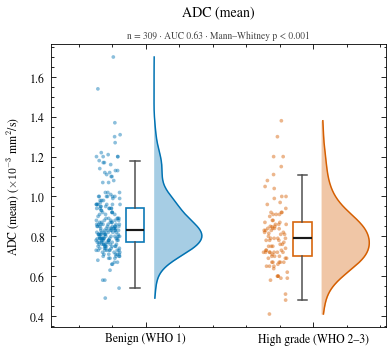

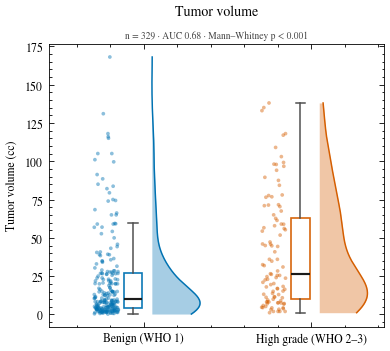

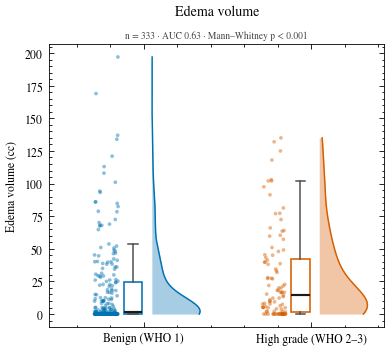

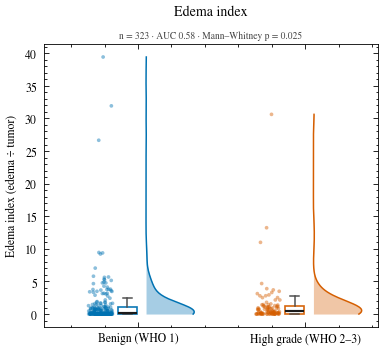

In [5]:
for metric in METRICS:
    art.figure(
        th.distribution_figure(df, metric, TARGET,
                               negative_label=NEGATIVE_LABEL,
                               positive_label=POSITIVE_LABEL),
        f"02_distribution_{metric.col}",
        caption=f"{metric.label} by WHO grade",
    )

---
# 04. Risk curves — the *"šķēre"*

**The question:** at what tumor volume, edema volume, or ADC does the probability of high grade start climbing fast?

**Why not a ROC.** Youden's *J* picks the split that separates the two grades best assuming a missed high-grade tumor and a false alarm cost the same. It is a statement about *separation*, not about *shape*. Risk could rise in a perfectly straight line and Youden would still hand you a confident-looking number — which, quoted as "the point where risk jumps", would be wrong.

**What is fitted.** A logistic regression of the outcome on the metric, with the metric entered as a **restricted cubic spline**: a curve built from cubic pieces joined at a few *knots* (join points) and forced to be straight beyond the outermost ones. Plain version: instead of assuming risk rises in a straight line, the data draw the shape — but the curve is not allowed to fly off in the tails where there are few patients.

Knots are placed at quantiles of the observed values (Harrell's convention: 10th, 50th, 90th percentile for three knots), so they land where the patients are. **Three knots** is the right choice at this sample size — with ~105 high-grade cases, four is the most a defensible fit will support, and the code drops to fewer automatically if the metric has too many tied values to place them (a quarter of this cohort has exactly zero edema).

## Three things come out, in decreasing order of trustworthiness

| Output | What it is | How much to lean on it |
|---|---|---|
| **The curve** | Predicted risk across the observed range, with a 95% band and the observed proportions in bins laid over it | Solid. Needs no threshold at all — this is the figure. |
| **Risk-level crossings** | "Predicted risk passes 30% / 50% at X" | Stable, and what clinicians actually ask for. |
| **Steepest-rise point** | The maximum of the curve's slope — literally the *"šķēre"* | Noisiest number here: a maximum of a derivative of a fitted curve. Only reported when it survives two tests. |

## Which scale the test runs on — and why it matters

**"Is the risk bent?" is not a scale-free question.** A relationship that is a straight line in log(volume) is a curve in volume. Same patients, same model, opposite answer:

| Tumor volume, non-linearity test | p |
|---|---|
| fitted on `log1p(cc)` | 0.97 — no bend |
| fitted on `cc` | 0.02 — real bend, knee at 12.7 cc |

The threshold gets **reported in cc**, so the test has to **run in cc**. Testing on the log scale and then quoting a cut-point in cc is incoherent. Harrell's quantile knots already put the flexibility where the patients are — which is what a log transform would have been for — so it is not needed and it changes the hypothesis.

The log-scale test is still run, and reported next to the primary result as `nonlinearity_p_log_scale` / `scale_sensitive`. A metric flagged `scale_sensitive` is one where the two disagree, and saying so is what keeps this from being a scale chosen to suit the answer.

## The two tests a threshold has to pass

A steepest-rise point is reported as a real threshold (`knee_found`) only when **both** hold:

1. **The non-linearity test fires** — a likelihood-ratio test of the spline against a plain straight line (p < 0.05). Without curvature there is no change in behaviour to locate.
2. **The maximum is interior** — measured in **patients, not axis units**. At least 5% of the cohort must lie on each side of it. Edema volume runs 0–116 cc but half the cohort sits below 4.5 cc: a knee at 3.5 cc is 3% along the axis and at the *48th percentile of patients*. Judging interiority by axis position throws away knees sitting in the middle of the data purely because the variable has a long tail. `steepest_pct_of_patients` reports where it landed.

⚠️ **The subtle half is the first one.** Even a perfectly straight log-odds relationship produces an *S-shaped probability curve*, whose slope always peaks somewhere in the middle — at exactly the 50% crossing. That peak is mathematically real but it is not a threshold effect: it tells you nothing the 50% crossing does not already tell you. Requiring genuine curvature first is what separates *"risk changes behaviour here"* from *"risk passes one half here"*.

When both tests fail, the honest finding is that **risk rises steadily and no threshold marks a jump** — a publishable result, not a failed analysis.

In [6]:
RISK_TABLE, CURVES = rc.risk_curve_summary(
    df, METRICS, TARGET,
    risk_levels=RISK_LEVELS,
    n_boot=N_BOOTSTRAP_CURVE,
    seed=BOOTSTRAP_SEED,
)

# Kept separately so the per-metric figures can draw the bootstrap band
# without refitting several hundred splines each.
CURVE_BOOTSTRAPS = {
    m.col: rc.bootstrap_risk_curve(
        *th.metric_arrays(df, m, TARGET),
        direction=m.direction, log_fit=m.log_x,
        risk_levels=RISK_LEVELS, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
    )
    for m in METRICS
}

art.table(RISK_TABLE, "03_risk_curves",
          caption="Non-linearity test, steepest-rise point, and risk crossings")

,metric,column,unit,direction,n,events,AUC,fitted_on,n_knots,nonlinearity_chi2,nonlinearity_df,nonlinearity_p,nonlinear,steepest_x,steepest_lo,steepest_hi,steepest_risk,steepest_slope_per_unit,steepest_at_boundary,steepest_pct_of_patients,knee_rate_boot,nonlinearity_p_log_scale,nonlinear_log_scale,scale_sensitive,knee_found,prevalence,n_bootstrap,verdict,note,risk_30_x,risk_30_lo,risk_30_hi,risk_30_found_frac,risk_50_x,risk_50_lo,risk_50_hi,risk_50_found_frac
0,ADC (mean),adc_value,$\times 10^{-3}$ mm$^2$/s,lower,309,96,0.63,raw x (clinical units),3,6.755,1,0.009,True,0.662,0.623,0.706,0.502,-1.752,False,7.1,0.616,0.015,True,False,True,0.311,500,Risk climbs most steeply near ADC (mean) 0.662...,,0.791,0.745,1.300,1.000,0.663,0.598,0.716,0.932
1,Tumor volume,tumor_volume,cc,higher,329,101,0.68,raw x (clinical units),3,5.330,1,0.021,True,12.718,9.932,17.009,0.250,0.009,False,46.8,0.636,0.974,False,True,True,0.307,500,Risk climbs most steeply near Tumor volume 12....,,18.519,12.617,29.293,1.000,62.262,32.482,101.869,0.802
2,Edema volume,edema_volume_cm3,cc,higher,333,99,0.63,raw x (clinical units),3,7.184,1,0.007,True,3.513,1.697,8.000,0.243,0.009,False,47.7,0.756,0.159,False,True,True,0.297,500,Risk climbs most steeply near Edema volume 3.5...,,9.923,3.418,21.656,0.996,,21.234,109.921,0.298
3,Edema index,edema_index,edema ÷ tumor,higher,323,98,0.58,raw x (clinical units),3,3.935,1,0.047,True,0.091,0.066,0.237,0.270,0.107,False,40.9,0.566,0.002,True,False,True,0.303,500,Risk climbs most steeply near Edema index 0.09...,,0.383,0.002,1.184,0.904,,0.893,11.909,0.054


💾 output/thresholds/tables/03_risk_curves.csv — 4 rows


,metric,column,unit,direction,n,events,AUC,fitted_on,n_knots,nonlinearity_chi2,nonlinearity_df,nonlinearity_p,nonlinear,steepest_x,steepest_lo,steepest_hi,steepest_risk,steepest_slope_per_unit,steepest_at_boundary,steepest_pct_of_patients,knee_rate_boot,nonlinearity_p_log_scale,nonlinear_log_scale,scale_sensitive,knee_found,prevalence,n_bootstrap,verdict,note,risk_30_x,risk_30_lo,risk_30_hi,risk_30_found_frac,risk_50_x,risk_50_lo,risk_50_hi,risk_50_found_frac
0,ADC (mean),adc_value,$\times 10^{-3}$ mm$^2$/s,lower,309,96,0.627054,raw x (clinical units),3,6.755446,1,0.009346,True,0.661894,0.623474,0.705714,0.502144,-1.752325,False,7.119741,0.616,0.015269,True,False,True,0.310680,500,Risk climbs most steeply near ADC (mean) 0.662...,,0.791268,0.744806,1.300000,1.000,0.663118,0.598194,0.716122,0.932
1,Tumor volume,tumor_volume,cc,higher,329,101,0.678696,raw x (clinical units),3,5.329580,1,0.020966,True,12.717588,9.931565,17.009340,0.249540,0.008877,False,46.808511,0.636,0.973834,False,True,True,0.306991,500,Risk climbs most steeply near Tumor volume 12....,,18.519291,12.616626,29.292965,1.000,62.261727,32.482201,101.869297,0.802
2,Edema volume,edema_volume_cm3,cc,higher,333,99,0.629068,raw x (clinical units),3,7.184318,1,0.007354,True,3.512563,1.696922,7.999598,0.243020,0.009227,False,47.747748,0.756,0.158691,False,True,True,0.297297,500,Risk climbs most steeply near Edema volume 3.5...,,9.922525,3.418077,21.655666,0.996,NaN,21.233603,109.920728,0.298
3,Edema index,edema_index,edema ÷ tumor,higher,323,98,0.576803,raw x (clinical units),3,3.934991,1,0.047291,True,0.091454,0.065565,0.237163,0.269910,0.107293,False,40.866873,0.566,0.001948,True,False,True,0.303406,500,Risk climbs most steeply near Edema index 0.09...,,0.383349,0.001846,1.183723,0.904,NaN,0.892777,11.909469,0.054


### The reading view

`Non-linear?` is the gatekeeper. `Steepest rise` says `no interior threshold` whenever either test failed — that is the module refusing to invent a number, not a missing value.

`Patients below it` is the sanity check on the threshold's position. A knee at the 47th percentile sits in the bulk of the cohort; one at the 7th is real but rests on comparatively few patients, and should be quoted with that caveat.

Intervals in brackets are percentile bootstrap intervals: the whole spline is refitted on each resample, so they cover knot placement and curve shape, not just the position of a maximum on one fixed curve. **Expect them to be wide.**

In [7]:
RISK_READING = rc.risk_curve_reading_view(RISK_TABLE)
art.table(RISK_READING, "04_risk_curves_reading_view", formatted=False,
          caption="Plain-language answer: is there a threshold, and where?")

,Metric,n / events,Non-linear?,Steepest rise,Patients below it,Risk reaches 30%,Risk reaches 50%,Reading
0,ADC (mean),309 / 96,yes (p = 0.009),0.662 (0.623–0.706),7%,0.791 (0.745–1.3),0.663 (0.598–0.716),Risk climbs most steeply near ADC (mean) 0.662...
1,Tumor volume,329 / 101,yes (p = 0.021),12.7 (9.93–17),47%,18.5 (12.6–29.3),62.3 (32.5–102),Risk climbs most steeply near Tumor volume 12....
2,Edema volume,333 / 99,yes (p = 0.007),3.51 (1.7–8),48%,9.92 (3.42–21.7),never reached,Risk climbs most steeply near Edema volume 3.5...
3,Edema index,323 / 98,yes (p = 0.047),0.0915 (0.0656–0.237),41%,0.383 (0.00185–1.18),never reached,Risk climbs most steeply near Edema index 0.09...


💾 output/thresholds/tables/04_risk_curves_reading_view.csv — 4 rows


,Metric,n / events,Non-linear?,Steepest rise,Patients below it,Risk reaches 30%,Risk reaches 50%,Reading
0,ADC (mean),309 / 96,yes (p = 0.009),0.662 (0.623–0.706),7%,0.791 (0.745–1.3),0.663 (0.598–0.716),Risk climbs most steeply near ADC (mean) 0.662...
1,Tumor volume,329 / 101,yes (p = 0.021),12.7 (9.93–17),47%,18.5 (12.6–29.3),62.3 (32.5–102),Risk climbs most steeply near Tumor volume 12....
2,Edema volume,333 / 99,yes (p = 0.007),3.51 (1.7–8),48%,9.92 (3.42–21.7),never reached,Risk climbs most steeply near Edema volume 3.5...
3,Edema index,323 / 98,yes (p = 0.047),0.0915 (0.0656–0.237),41%,0.383 (0.00185–1.18),never reached,Risk climbs most steeply near Edema index 0.09...


### All four curves — the poster figure

No cut-points, no rules: just how the probability of high grade moves with each measurement, and how wide the uncertainty around that is. The grey dots are the **observed** proportion in equal-count bins with Wilson intervals — the honesty check on the fit. If they do not track the blue curve, the spline is telling a story the patients do not support.

The dash-dotted horizontal line is the cohort's own high-grade rate; a curve that never leaves it is a metric that carries no information.

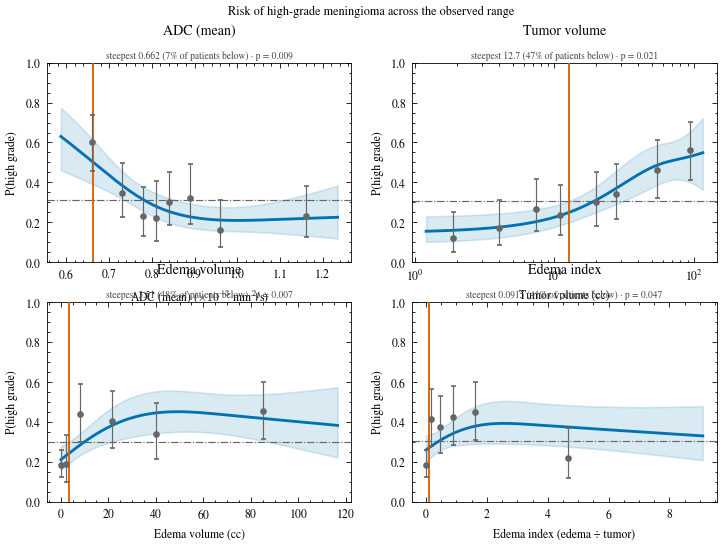

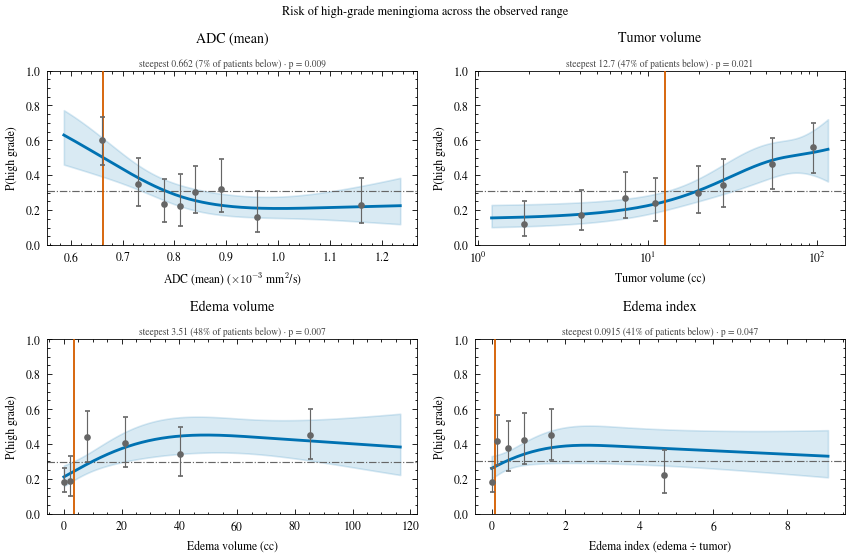

In [8]:
art.figure(rc.risk_curve_panel(df, METRICS, TARGET, CURVES), "05_risk_curves_panel",
           caption="Risk of high-grade meningioma across the observed range")

### Per metric, with the slope drawn

The right-hand panel is the direct answer to Balodis's question: it plots the **rise in risk per unit of the metric**, so its peak *is* the steepest-rise point. A right panel with no peak — flat, or highest at an edge — is the finding that no such point exists.

The vertical line is drawn solid and labelled only when the threshold passed both tests; otherwise it is dashed and labelled "not a threshold".

/Users/andriszaguzovs/.pyenv/versions/3.12.13/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)


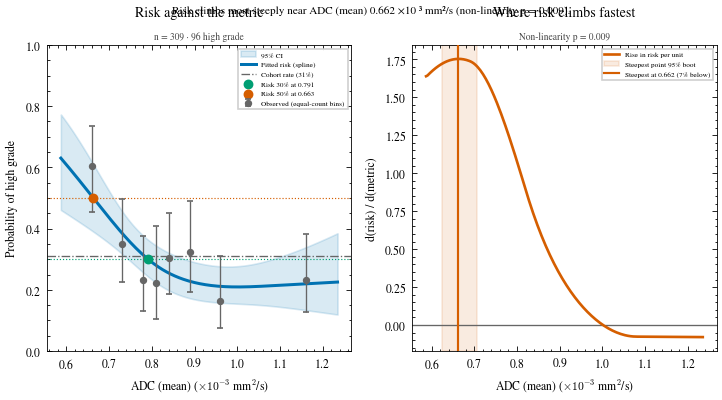

/Users/andriszaguzovs/TheLibraryOfCode/meningioma-atypier/heavy_machinery/modelling_phase/plot_style.py:922: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  fig.tight_layout()
/Users/andriszaguzovs/TheLibraryOfCode/meningioma-atypier/heavy_machinery/modelling_phase/plot_style.py:926: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  fig.savefig(out, **kwargs)


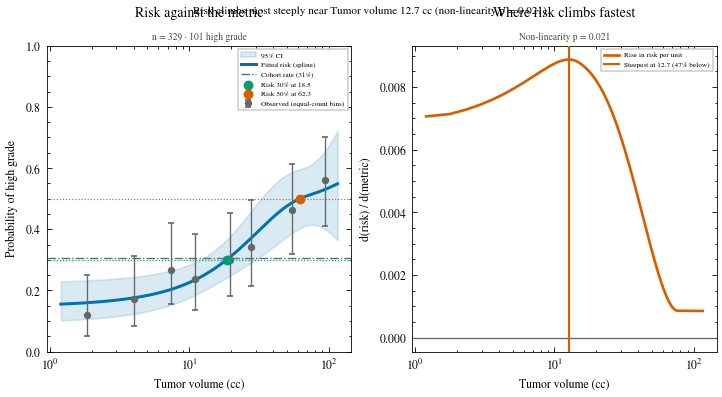

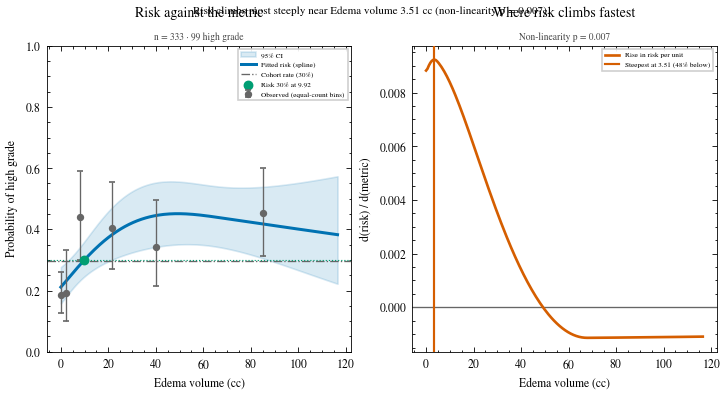

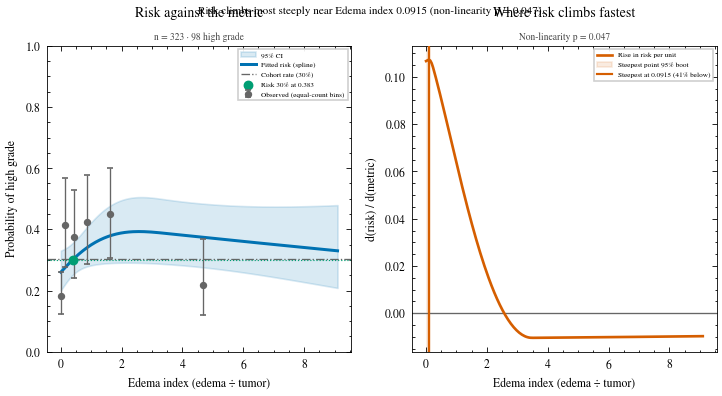

In [9]:
for metric in METRICS:
    art.figure(
        rc.risk_curve_figure(df, metric, TARGET, CURVES[metric.col],
                             boot=CURVE_BOOTSTRAPS[metric.col],
                             risk_levels=RISK_LEVELS),
        f"06_risk_curve_{metric.col}",
        caption=CURVES[metric.col].verdict(metric),
    )

### What §04 concluded

One line per metric, in the words you would put under the figure.

In [10]:
for metric in METRICS:
    curve = CURVES[metric.col]
    mark = "🎯" if curve.knee_found else "➖"
    print(f"{mark} {curve.verdict(metric)}")
    art.note(curve.verdict(metric))

🎯 Risk climbs most steeply near ADC (mean) 0.662 ×10⁻³ mm²/s (non-linearity p = 0.009).
🎯 Risk climbs most steeply near Tumor volume 12.7 cc (non-linearity p = 0.021).
🎯 Risk climbs most steeply near Edema volume 3.51 cc (non-linearity p = 0.007).
🎯 Risk climbs most steeply near Edema index 0.0915 (non-linearity p = 0.047).


### Zero inflation — "no edema" is a category, not a small number

A third of this cohort has **no peritumoral edema at all**. That breaks the whole-cohort
spline in a specific way: Harrell's knots go at the 10th, 50th and 90th percentile, so the
lowest knot lands *at zero*, and the bend the model then finds is substantially the
difference between **edema present and edema absent** — a distinction a radiologist makes
by looking, not by measuring.

So the claim is split into three, and the report says which one is defensible:

1. **How many are exactly zero**, and what the risk is on each side of that.
2. **`edema present (> 0)` as a rule in its own right** — the comparator the measured
   cut-point has to beat. If a rule needing no measurement performs as well, the
   measurement is not what is doing the work.
3. **The curve refitted on patients with a non-zero value**, with its own knee and
   interval. That is the honest version of *"above what volume of edema…"*.

In [11]:
ZERO_SHARE = rc.zero_share(df, METRICS, TARGET)
art.table(ZERO_SHARE, "34_zero_inflation",
          caption="Exact zeros per metric, with the risk on each side of zero")

PRESENCE_RULES = rc.presence_rules(df, METRICS, TARGET)
art.table(PRESENCE_RULES, "35_presence_rules",
          caption='"Is there any at all?" scored as a yes/no test, with the full 2x2')

# Refit the curve where the metric is a measurement rather than a category.
ZERO_INFLATED = [m for m in METRICS
                 if bool(ZERO_SHARE.set_index("column").loc[m.col, "zero_inflated"])]
POSITIVE_RISK_TABLE = pd.DataFrame()
if ZERO_INFLATED:
    parts = []
    for metric in ZERO_INFLATED:
        subset = rc.positive_only(df, metric)
        part, _ = rc.risk_curve_summary(
            subset, [metric], TARGET, risk_levels=RISK_LEVELS,
            n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
        )
        parts.append(part)
    POSITIVE_RISK_TABLE = pd.concat(parts, ignore_index=True)
    art.table(POSITIVE_RISK_TABLE, "36_risk_curves_nonzero_only",
              caption="Risk curves refitted on patients with a non-zero value")

    COMPARISONS = pd.concat(
        [rc.zero_inflation_comparison(RISK_TABLE, PRESENCE_RULES,
                                      POSITIVE_RISK_TABLE, m).assign(Metric=m.label)
         for m in ZERO_INFLATED],
        ignore_index=True,
    )
    art.table(COMPARISONS, "37_zero_inflation_comparison", formatted=False,
              caption="Whole cohort vs present/absent vs non-zero only, side by side")

for _, r in ZERO_SHARE[ZERO_SHARE["zero_inflated"]].iterrows():
    note = (
        f"{r['metric']} is zero in {r['n_zero']} of {r['n_analysed']} measured patients "
        f"({r['pct_zero']:.1f}%). Risk is {r['risk_zero'] * 100:.0f}% "
        f"({r['risk_zero_lo'] * 100:.0f}-{r['risk_zero_hi'] * 100:.0f}) with none and "
        f"{r['risk_positive'] * 100:.0f}% "
        f"({r['risk_positive_lo'] * 100:.0f}-{r['risk_positive_hi'] * 100:.0f}) with any, "
        f"a {r['risk_ratio']:.1f}-fold difference before any cut-point is drawn."
    )
    print(f"\u26a0\ufe0f {note}")
    art.note(note)

,metric,column,n_analysed,n_zero,pct_zero,n_positive,smallest_positive,events_zero,risk_zero,risk_zero_lo,risk_zero_hi,events_positive,risk_positive,risk_positive_lo,risk_positive_hi,risk_ratio,zero_inflated,zero_inflation_floor_pct
0,ADC (mean),adc_value,309,0,0.0,309,0.41,0,,,,96,0.311,0.262,0.364,,False,10
1,Tumor volume,tumor_volume,329,0,0.0,329,0.30,0,,,,101,0.307,0.260,0.359,,False,10
2,Edema volume,edema_volume_cm3,333,122,36.6,211,0.20,23,0.189,0.129,0.267,76,0.360,0.298,0.427,1.911,True,10
3,Edema index,edema_index,323,113,35.0,210,0.01,22,0.195,0.132,0.277,76,0.362,0.300,0.429,1.859,True,10


💾 output/thresholds/tables/34_zero_inflation.csv — 4 rows


,predictor,n_used,TP,FP,FN,TN,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,PPV,PPV_lo,PPV_hi,NPV,NPV_lo,NPV_hi,accuracy,accuracy_lo,accuracy_hi,AUC,p,test,note,metric,column,rule,rule_label,youden_J
0,Edema volume present (> 0),333,76,135,23,99,0.768,0.675,0.840,0.423,0.362,0.487,0.360,0.298,0.427,0.811,0.733,0.871,0.526,0.472,0.579,0.60,<0.001,chi2,,Edema volume,edema_volume_cm3,presence,Edema volume present (> 0),0.191
1,Edema index present (> 0),323,76,134,22,91,0.776,0.683,0.847,0.404,0.342,0.470,0.362,0.300,0.429,0.805,0.723,0.868,0.517,0.463,0.571,0.59,0.002,chi2,,Edema index,edema_index,presence,Edema index present (> 0),0.180


💾 output/thresholds/tables/35_presence_rules.csv — 2 rows


,metric,column,unit,direction,n,events,AUC,fitted_on,n_knots,nonlinearity_chi2,nonlinearity_df,nonlinearity_p,nonlinear,steepest_x,steepest_lo,steepest_hi,steepest_risk,steepest_slope_per_unit,steepest_at_boundary,steepest_pct_of_patients,knee_rate_boot,nonlinearity_p_log_scale,nonlinear_log_scale,scale_sensitive,knee_found,prevalence,n_bootstrap,verdict,note,risk_30_x,risk_30_lo,risk_30_hi,risk_30_found_frac,risk_50_x,risk_50_lo,risk_50_hi,risk_50_found_frac
0,Edema volume,edema_volume_cm3,cc,higher,211,76,0.58,raw x (clinical units),3,1.796,1,0.180,False,7.738,5.998,14.514,0.312,0.005,False,29.4,0.260,0.125,False,False,False,0.360,500,Risk rises steadily with Edema volume — no cur...,,5.332,0.602,32.701,0.728,,26.875,119.087,0.304
1,Edema index,edema_index,edema ÷ tumor,higher,210,76,0.47,raw x (clinical units),3,0.176,1,0.675,False,10.644,0.161,0.399,0.297,-0.005,True,97.1,0.044,0.331,False,False,False,0.362,500,Risk rises steadily with Edema index — no curv...,,0.023,0.013,0.386,0.700,,0.016,26.264,0.086


💾 output/thresholds/tables/36_risk_curves_nonzero_only.csv — 2 rows


,Fitted on,n,Non-linearity p,Steepest rise,95% CI,Metric
0,Whole cohort (zeros included),333 (99 high grade),= 0.007,3.51,1.7–8,Edema volume
1,Present vs absent (no measurement needed),333 (99 high grade),n/a — binary,"sens 77% / spec 42%, J 0.19",—,Edema volume
2,Only patients with a non-zero value,211 (76 high grade),= 0.180,no interior threshold,—,Edema volume
3,Whole cohort (zeros included),323 (98 high grade),= 0.047,0.0915,0.0656–0.237,Edema index
4,Present vs absent (no measurement needed),323 (98 high grade),n/a — binary,"sens 78% / spec 40%, J 0.18",—,Edema index
5,Only patients with a non-zero value,210 (76 high grade),= 0.675,no interior threshold,—,Edema index


💾 output/thresholds/tables/37_zero_inflation_comparison.csv — 6 rows
⚠️ Edema volume is zero in 122 of 333 measured patients (36.6%). Risk is 19% (13-27) with none and 36% (30-43) with any, a 1.9-fold difference before any cut-point is drawn.
⚠️ Edema index is zero in 113 of 323 measured patients (35.0%). Risk is 19% (13-28) with none and 36% (30-43) with any, a 1.9-fold difference before any cut-point is drawn.


---
# 05. Single cut-points

A different question from §04: **not** where risk changes shape, but where to draw one line so the two grades separate as well as possible.

The engine builds one table per metric containing **every cut-point the data can distinguish** — the ROC curve is exactly this table — with:

| Column | Meaning |
|---|---|
| `cutoff` | candidate cut-point, on the metric's own scale |
| `sensitivity` | of the high-grade tumors, the fraction flagged |
| `specificity` | of the benign tumors, the fraction not flagged |
| `youden_j` | `sensitivity + specificity − 1`; 0 for a coin flip, 1 for perfect |
| `dist_01` | distance from the ROC point to the perfect corner |

Cut-points that flag **everyone** or **no one** are dropped — they are not tests, and they make the 2×2 table degenerate.

## The five selection rules

The first three are **symmetric**: they assume a missed high-grade tumor and a false alarm cost the same. The last two are **constrained**: you fix the error you refuse to make and take the best of the rest, which is usually the honest way to state a clinical requirement.

| Rule | Picks | Use when |
|---|---|---|
| `youden` | max(sens + spec − 1) | the field convention; prevalence-free |
| `closest_01` | nearest ROC point to the perfect corner | as above, slightly different tie-breaking |
| `equal_sens_spec` | where the two curves cross | you want equal error rates, not the optimum |
| `spec_ge_90` | best sensitivity while specificity ≥ 90% | **rule-in** — you will act on a positive |
| `sens_ge_90` | best specificity while sensitivity ≥ 90% | **rule-out** — you must not miss one |

## Why every number here is optimistic

Each rule takes a **maximum over hundreds of candidates on the same patients it is then scored on**. Sensitivity and specificity quoted at a cut-point that was chosen to maximise them are biased upward, always.

Two bootstrap quantities measure that, both by resampling patients with replacement:

- **A percentile interval for the cut-point itself** — how far the number moves if you had recruited a different ~350 patients. Wide intervals are the norm here, not a bug.
- **Optimism-corrected `J`** (Harrell's method, the same correction the modelling notebook applies to AUC) — pick the cut-point on the resample, score it back on the original cohort, average the gap. `J (corr.)` is what is left after subtracting it.

Published cut-points are appended under the rule name `literature`. They get **no** correction, and that is the point: they were not estimated here, so they carry no optimism from this cohort. Validating an external cut-point is the stronger study design.

In [12]:
# 🟧 Published cut-points to score alongside the data-driven ones.
#    {column: [(cutoff, source), ...]} — direction comes from the Metric.
#    The first two are already baked into cleaning as derived flags; scoring
#    them here is how you find out whether they transfer to this cohort.
LITERATURE_CUTOFFS: dict[str, list[tuple[float, str]]] = {
    "edema_volume_cm3": [(3.64, "Adeli, Spille et al., Oncotarget 2018;9(89):35974-35982")],
    "tumor_volume": [(13.95, "Shin, Kim, Cheong et al., PLoS One 2021;16(6):e0252945")],
    # "adc_value": [(0.85, "🟧 add your ADC reference here")],
}

THRESHOLD_TABLE = th.threshold_summary(
    df, METRICS, TARGET,
    literature_cutoffs=LITERATURE_CUTOFFS,
    n_boot=N_BOOTSTRAP,
    seed=BOOTSTRAP_SEED,
)
art.table(THRESHOLD_TABLE, "07_threshold_summary",
          caption="Every metric × rule, plus published cut-points, with Wilson CIs")

,metric,column,rule,operator,cutoff,cutoff_boot_lo,cutoff_boot_hi,n_used,TP,FP,FN,TN,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,PPV,PPV_lo,PPV_hi,NPV,NPV_lo,NPV_hi,youden_J,youden_J_corrected,optimism,accuracy,p,test,n_bootstrap,rule_note,source,note,predictor,accuracy_lo,accuracy_hi,AUC
0,ADC (mean),adc_value,youden,≤,0.72,0.69,0.85,309.0,34.0,25.0,62.0,188.0,0.354,0.266,0.454,0.883,0.832,0.919,0.576,0.449,0.694,0.752,0.695,0.801,0.237,0.209,0.028,0.718,<0.001,chi2,2000.0,"max(sens + spec − 1) — symmetric, prevalence-free",,,adc_value ≤ 0.72,0.666,0.766,0.62
1,ADC (mean),adc_value,closest_01,≤,0.79,0.73,0.848,309.0,51.0,78.0,45.0,135.0,0.531,0.432,0.628,0.634,0.567,0.696,0.395,0.315,0.482,0.75,0.682,0.808,0.165,0.133,0.032,0.602,0.006,chi2,2000.0,nearest ROC point to the perfect corner,,,adc_value ≤ 0.79,0.546,0.655,0.58
2,ADC (mean),adc_value,equal_sens_spec,≤,0.81,0.79,0.83,309.0,54.0,93.0,42.0,120.0,0.562,0.463,0.657,0.563,0.496,0.628,0.367,0.294,0.448,0.741,0.668,0.802,0.126,0.127,-0.001,0.563,0.04,chi2,2000.0,where the sens and spec curves cross,,,adc_value ≤ 0.81,0.507,0.617,0.56
3,ADC (mean),adc_value,spec_ge_90,≤,0.7,0.67,0.72,309.0,26.0,17.0,70.0,196.0,0.271,0.192,0.367,0.92,0.876,0.95,0.605,0.456,0.736,0.737,0.681,0.786,0.191,0.187,0.004,0.718,<0.001,chi2,2000.0,best sens while spec ≥ 90% — rule-in,,,adc_value ≤ 0.7,0.666,0.766,0.6
4,ADC (mean),adc_value,sens_ge_90,≤,1.0,0.92,1.15,309.0,87.0,182.0,9.0,31.0,0.906,0.831,0.95,0.146,0.104,0.199,0.323,0.27,0.381,0.775,0.625,0.877,0.052,0.045,0.007,0.382,0.209,chi2,2000.0,best spec while sens ≥ 90% — rule-out,,,adc_value ≤ 1,0.329,0.437,0.53
5,Tumor volume,tumor_volume,youden,≥,15.1,6.78,44.8,329.0,68.0,91.0,33.0,137.0,0.673,0.577,0.757,0.601,0.536,0.662,0.428,0.353,0.505,0.806,0.74,0.858,0.274,0.229,0.046,0.623,<0.001,chi2,2000.0,"max(sens + spec − 1) — symmetric, prevalence-free",,,tumor_volume ≥ 15.1,0.57,0.674,0.64
6,Tumor volume,tumor_volume,closest_01,≥,16.4,10.9,31.0,329.0,66.0,87.0,35.0,141.0,0.653,0.557,0.739,0.618,0.554,0.679,0.431,0.356,0.511,0.801,0.736,0.853,0.272,0.245,0.027,0.629,<0.001,chi2,2000.0,nearest ROC point to the perfect corner,,,tumor_volume ≥ 16.4,0.576,0.68,0.64
7,Tumor volume,tumor_volume,equal_sens_spec,≥,17.1,14.0,22.01,329.0,63.0,87.0,38.0,141.0,0.624,0.526,0.712,0.618,0.554,0.679,0.42,0.344,0.5,0.788,0.722,0.841,0.242,0.243,-0.001,0.62,<0.001,chi2,2000.0,where the sens and spec curves cross,,,tumor_volume ≥ 17.1,0.567,0.671,0.62
8,Tumor volume,tumor_volume,spec_ge_90,≥,61.4,44.8,77.6,329.0,27.0,22.0,74.0,206.0,0.267,0.191,0.361,0.904,0.858,0.935,0.551,0.413,0.681,0.736,0.681,0.784,0.171,0.162,0.008,0.708,<0.001,chi2,2000.0,best sens while spec ≥ 90% — rule-in,,,tumor_volume ≥ 61.4,0.657,0.755,0.59
9,Tumor volume,tumor_volume,sens_ge_90,≥,4.51,3.2,7.52,329.0,91.0,166.0,10.0,62.0,0.901,0.827,0.945,0.272,0.218,0.333,0.354,0.298,0.414,0.861,0.763,0.923,0.173,0.164,0.009,0.465,<0.001,chi2,2000.0,best spec while sens ≥ 90% — rule-out,,,tumor_volume ≥ 4.51,0.412,0.519,0.59


💾 output/thresholds/tables/07_threshold_summary.csv — 22 rows


,metric,column,rule,operator,cutoff,cutoff_boot_lo,cutoff_boot_hi,n_used,TP,FP,FN,TN,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,PPV,PPV_lo,PPV_hi,NPV,NPV_lo,NPV_hi,youden_J,youden_J_corrected,optimism,accuracy,p,test,n_bootstrap,rule_note,source,note,predictor,accuracy_lo,accuracy_hi,AUC
0,ADC (mean),adc_value,youden,≤,0.720000,0.690000,0.850000,309.0,34.0,25.0,62.0,188.0,0.354167,0.265798,0.453757,0.882629,0.832478,0.919223,0.576271,0.449345,0.693873,0.752000,0.694924,0.801448,0.236796,0.208752,0.028043,0.718447,9.536159e-07,chi2,2000.0,"max(sens + spec − 1) — symmetric, prevalence-free",,,adc_value ≤ 0.72,0.665854,0.765675,0.618398
1,ADC (mean),adc_value,closest_01,≤,0.790000,0.730000,0.848000,309.0,51.0,78.0,45.0,135.0,0.531250,0.432156,0.627939,0.633803,0.567266,0.695599,0.395349,0.315177,0.481573,0.750000,0.681965,0.807587,0.165053,0.132970,0.032083,0.601942,6.475488e-03,chi2,2000.0,nearest ROC point to the perfect corner,,,adc_value ≤ 0.79,0.546433,0.654947,0.582526
2,ADC (mean),adc_value,equal_sens_spec,≤,0.810000,0.790000,0.830000,309.0,54.0,93.0,42.0,120.0,0.562500,0.462759,0.657432,0.563380,0.496235,0.628280,0.367347,0.293719,0.447732,0.740741,0.668235,0.802093,0.125880,0.126674,-0.000793,0.563107,4.032192e-02,chi2,2000.0,where the sens and spec curves cross,,,adc_value ≤ 0.81,0.507364,0.617300,0.562940
3,ADC (mean),adc_value,spec_ge_90,≤,0.700000,0.670000,0.720000,309.0,26.0,17.0,70.0,196.0,0.270833,0.192038,0.367263,0.920188,0.875914,0.949574,0.604651,0.455791,0.736347,0.736842,0.680822,0.786118,0.191021,0.187381,0.003640,0.718447,7.134539e-06,chi2,2000.0,best sens while spec ≥ 90% — rule-in,,,adc_value ≤ 0.7,0.665854,0.765675,0.595511
4,ADC (mean),adc_value,sens_ge_90,≤,1.000000,0.920000,1.150000,309.0,87.0,182.0,9.0,31.0,0.906250,0.831347,0.949892,0.145540,0.104464,0.199174,0.323420,0.270345,0.381467,0.775000,0.624969,0.876839,0.051790,0.044985,0.006805,0.381877,2.094788e-01,chi2,2000.0,best spec while sens ≥ 90% — rule-out,,,adc_value ≤ 1,0.329470,0.437185,0.525895
5,Tumor volume,tumor_volume,youden,≥,15.100000,6.780000,44.800000,329.0,68.0,91.0,33.0,137.0,0.673267,0.576916,0.756921,0.600877,0.536146,0.662265,0.427673,0.353372,0.505386,0.805882,0.739941,0.858305,0.274145,0.228511,0.045633,0.623100,4.439216e-06,chi2,2000.0,"max(sens + spec − 1) — symmetric, prevalence-free",,,tumor_volume ≥ 15.1,0.569598,0.673761,0.637072
6,Tumor volume,tumor_volume,closest_01,≥,16.400000,10.900000,31.000000,329.0,66.0,87.0,35.0,141.0,0.653465,0.556580,0.739105,0.618421,0.553898,0.679019,0.431373,0.355525,0.510582,0.801136,0.736015,0.853393,0.271886,0.244805,0.027081,0.629179,5.103443e-06,chi2,2000.0,nearest ROC point to the perfect corner,,,tumor_volume ≥ 16.4,0.575775,0.679602,0.635943
7,Tumor volume,tumor_volume,equal_sens_spec,≥,17.100000,14.000000,22.010000,329.0,63.0,87.0,38.0,141.0,0.623762,0.526386,0.712069,0.618421,0.553898,0.679019,0.420000,0.343980,0.500015,0.787709,0.722084,0.841246,0.242183,0.242849,-0.000666,0.620061,4.738524e-05,chi2,2000.0,where the sens and spec curves cross,,,tumor_volume ≥ 17.1,0.566513,0.670837,0.621092
8,Tumor volume,tumor_volume,spec_ge_90,≥,61.400000,44.800000,77.600000,329.0,27.0,22.0,74.0,206.0,0.267327,0.190710,0.360994,0.903509,0.858232,0.935413,0.551020,0.413151,0.681472,0.735714,0.681127,0.783921,0.170836,0.162485,0.008351,0.708207,5.958204e-05,chi2,2000.0,best sens while spec ≥ 90% — rule-in,,,tumor_volume ≥ 61.4,0.656908,0.754700,0.585418
9,Tumor volume,tumor_volume,sens_ge_90,≥,4.510000,3.200000,7.520000,329.0,91.0,166.0,10.0,62.0,0.900990,0.827268,0.945327,0.271930,0.218309,0.333109,0.354086,0.298158,0.414311,0.861111,0.762868,0.922773,0.172920,0.163818,0.009102,0.465046,4.670864e-04,chi2,2000.0,best spec while sens ≥ 90% — rule-out,,,tumor_volume ≥ 4.51,0.411863,0.519035,0.586460


### Reading view

The columns a clinician actually reads, with the confidence intervals folded into the estimate. The gap between `J` and `J (corr.)` is what you lose by having chosen the cut-point on this same cohort.

In [13]:
THRESHOLD_READING = th.reading_view(THRESHOLD_TABLE)
art.table(THRESHOLD_READING, "08_threshold_reading_view", formatted=False,
          caption="Cut-points with sensitivity, specificity, PPV, NPV and optimism-corrected J")

,Metric,Rule,Cut-point,Cut-point 95% CI,n,Sens (95% CI),Spec (95% CI),PPV (95% CI),NPV (95% CI),J,J (corr.)
0,ADC (mean),youden,≤0.72,0.69–0.85,309.0,35% (27–45),88% (83–92),58% (45–69),75% (69–80),0.24,0.21
1,ADC (mean),closest_01,≤0.79,0.73–0.848,309.0,53% (43–63),63% (57–70),40% (32–48),75% (68–81),0.17,0.13
2,ADC (mean),equal_sens_spec,≤0.81,0.79–0.83,309.0,56% (46–66),56% (50–63),37% (29–45),74% (67–80),0.13,0.13
3,ADC (mean),spec_ge_90,≤0.7,0.67–0.72,309.0,27% (19–37),92% (88–95),60% (46–74),74% (68–79),0.19,0.19
4,ADC (mean),sens_ge_90,≤1,0.92–1.15,309.0,91% (83–95),15% (10–20),32% (27–38),78% (62–88),0.05,0.04
5,Tumor volume,youden,≥15.1,6.78–44.8,329.0,67% (58–76),60% (54–66),43% (35–51),81% (74–86),0.27,0.23
6,Tumor volume,closest_01,≥16.4,10.9–31,329.0,65% (56–74),62% (55–68),43% (36–51),80% (74–85),0.27,0.24
7,Tumor volume,equal_sens_spec,≥17.1,14–22,329.0,62% (53–71),62% (55–68),42% (34–50),79% (72–84),0.24,0.24
8,Tumor volume,spec_ge_90,≥61.4,44.8–77.6,329.0,27% (19–36),90% (86–94),55% (41–68),74% (68–78),0.17,0.16
9,Tumor volume,sens_ge_90,≥4.51,3.2–7.52,329.0,90% (83–95),27% (22–33),35% (30–41),86% (76–92),0.17,0.16


💾 output/thresholds/tables/08_threshold_reading_view.csv — 22 rows


,Metric,Rule,Cut-point,Cut-point 95% CI,n,Sens (95% CI),Spec (95% CI),PPV (95% CI),NPV (95% CI),J,J (corr.)
0,ADC (mean),youden,≤0.72,0.69–0.85,309.0,35% (27–45),88% (83–92),58% (45–69),75% (69–80),0.24,0.21
1,ADC (mean),closest_01,≤0.79,0.73–0.848,309.0,53% (43–63),63% (57–70),40% (32–48),75% (68–81),0.17,0.13
2,ADC (mean),equal_sens_spec,≤0.81,0.79–0.83,309.0,56% (46–66),56% (50–63),37% (29–45),74% (67–80),0.13,0.13
3,ADC (mean),spec_ge_90,≤0.7,0.67–0.72,309.0,27% (19–37),92% (88–95),60% (46–74),74% (68–79),0.19,0.19
4,ADC (mean),sens_ge_90,≤1,0.92–1.15,309.0,91% (83–95),15% (10–20),32% (27–38),78% (62–88),0.05,0.04
5,Tumor volume,youden,≥15.1,6.78–44.8,329.0,67% (58–76),60% (54–66),43% (35–51),81% (74–86),0.27,0.23
6,Tumor volume,closest_01,≥16.4,10.9–31,329.0,65% (56–74),62% (55–68),43% (36–51),80% (74–85),0.27,0.24
7,Tumor volume,equal_sens_spec,≥17.1,14–22,329.0,62% (53–71),62% (55–68),42% (34–50),79% (72–84),0.24,0.24
8,Tumor volume,spec_ge_90,≥61.4,44.8–77.6,329.0,27% (19–36),90% (86–94),55% (41–68),74% (68–78),0.17,0.16
9,Tumor volume,sens_ge_90,≥4.51,3.2–7.52,329.0,90% (83–95),27% (22–33),35% (30–41),86% (76–92),0.17,0.16


### Youden vs the whole trade-off

Both panels below come from **the same ROC table**. They differ in what they hide.

**Left — ROC with the Youden point.** One point per candidate cut-point. Youden's *J* is the **vertical distance from the curve up off the diagonal**, drawn as a short vertical line; the rule picks where that gap is largest. Output: one number, under a symmetric-cost assumption, ignoring prevalence. That is why it is the radiology default — and why it is a *convention*, not an optimum for your clinic.

**Right — sensitivity and specificity against the cut-point.** Not a rule; a *display*. The cut-point is on the x-axis, so you read off what any candidate would cost. Three things become visible that the ROC hides:

1. **How flat the peak is.** If `J` is flat across a wide band, the "optimal" cut-point is one of many near-equivalent choices and quoting it to three decimals is false precision. The shaded bootstrap band under the peak says the same thing in cut-point units.
2. **Where the curves cross** (sens = spec). This is a *different* cut-point from Youden in general — they coincide only if the two grade distributions are mirror images. The crossing is frequently mistaken for "the optimum"; it is the point of equal error rates and usually has a lower `J`.
3. **Where a clinical constraint lands.** "I will not call a tumor high grade unless specificity is ≥ 90%" is a horizontal line here, and the cut-point is where the specificity curve crosses it. This is the honest way to encode an asymmetric cost, and it requires no pretence that a maximum was found.

**Short version:** Youden *chooses* for you under an assumption you probably do not hold; the right panel *shows* you the trade-off so you can choose under your own costs — and shows you how much the choice actually matters.

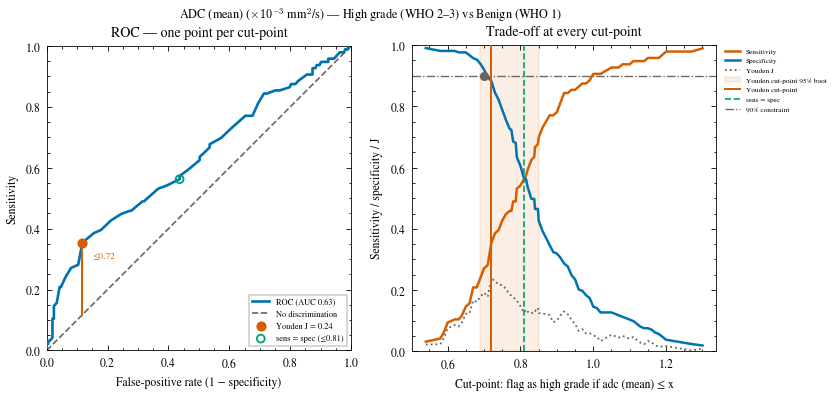

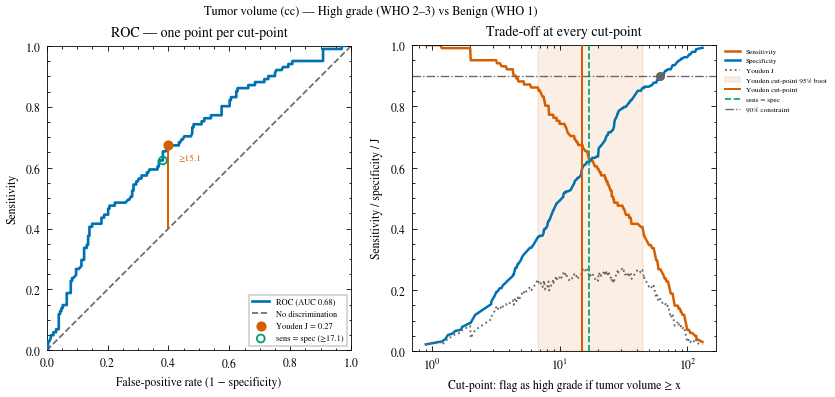

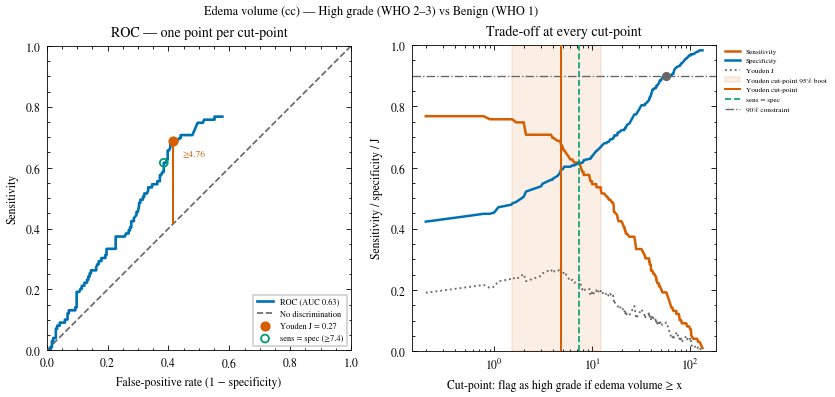

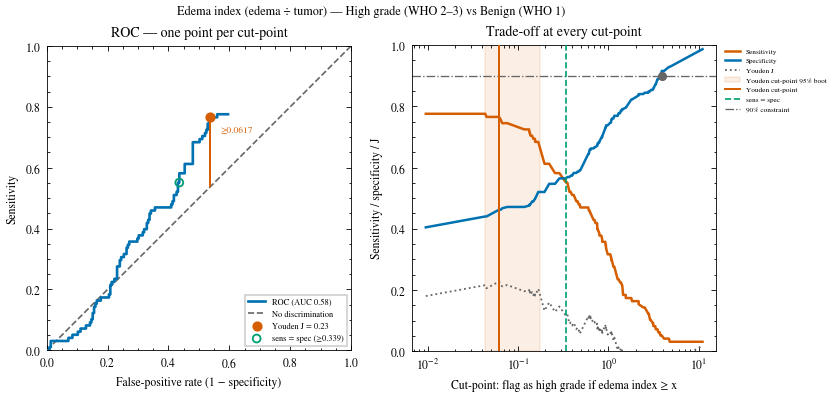

In [14]:
for metric in METRICS:
    art.figure(
        th.threshold_figure(df, metric, TARGET, n_boot=N_BOOTSTRAP, seed=BOOTSTRAP_SEED,
                            positive_label=POSITIVE_LABEL, negative_label=NEGATIVE_LABEL),
        f"09_thresholds_{metric.col}",
        caption=f"{metric.label}: ROC and the full cut-point trade-off",
    )

### All metrics on one ROC

The discrimination comparison, independent of any cut-point choice. A curve that hugs the diagonal belongs to a metric with no cut-point worth arguing about.

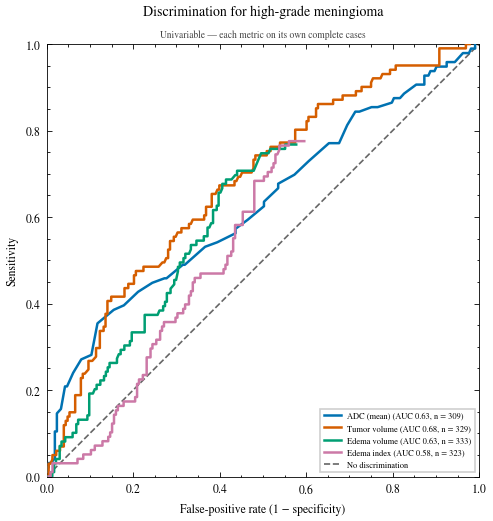

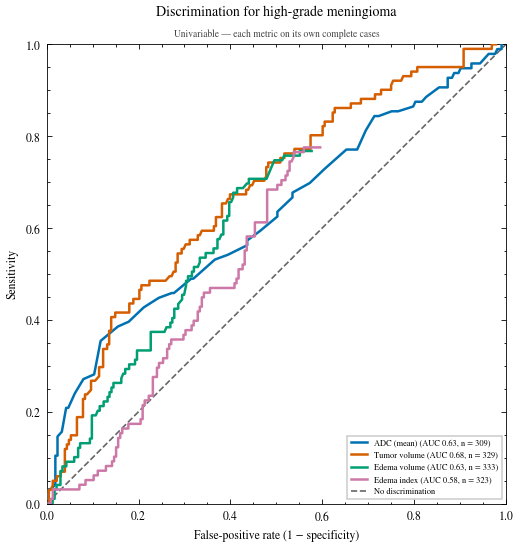

In [15]:
art.figure(th.combined_roc_figure(df, METRICS, TARGET), "10_combined_roc",
           caption="Univariable discrimination, each metric on its own complete cases")

---
# 06. Combinations — do two cut-points beat one?

Balodis's second question. The design decision that makes it defensible:

> **The cut-points are frozen before they are combined.**

They come from §05 (or from the literature) and only the *way of joining them* varies here. Searching over cut-points **and** combination rules at once would be thousands of comparisons on 105 events, and every "improvement" found that way would be noise.

## Three families of combined rule

| Family | Rule | What it buys, what it spends |
|---|---|---|
| **AND** | both flags positive | buys specificity, spends sensitivity — *rule in* |
| **OR** | either flag positive | buys sensitivity, spends specificity — *rule out* |
| **count** | how many of the *k* flags are positive, used as a score | no logic gates to remember; the clinically usable form |

## Three benchmarks any claim of improvement must clear

1. **The best single cut-point** — literally the comparison asked for.
2. **A logistic model on the uncut, continuous metrics.** The strong benchmark. Dichotomising throws information away, so a combined rule that cannot beat this is evidence that cutting the variables up was the wrong move.
3. **Selection optimism.** The winner of a dozen candidate rules always looks better on the data that crowned it. The bootstrap here rebuilds the whole menu on each resample, picks that resample's winner, and re-scores *that same rule* on the original cohort. It also reports `winner_stability` — how often the same rule wins at all. Below roughly 0.5, "the best combination" is a coin toss between near-equivalent rules, not a finding.

## Missing values

Flags follow **Kleene logic** (three-valued: true / false / unknown). `False AND unknown` is `False`, because one negative flag already settles an AND rule; `True AND unknown` stays unknown. This keeps as many patients as possible in each rule, and every row reports its own `n_used`. The count score is stricter — it needs *all* flags observed, because "2 of 4" means something different when one of the four was never measured.

In [16]:
# 🟧 Which rule freezes the cut-points. "youden" is the field convention;
#    swap for "spec_ge_90" to build a rule-in combination instead.
COMBINATION_RULE = "youden"

CUTPOINTS = cb.cutpoints_for_rule(df, METRICS, TARGET, COMBINATION_RULE)

# Published cut-points combined with each other need no optimism correction at
# all — nothing about them was chosen on these patients.
LITERATURE_CUTPOINTS = cb.cutpoints_from_literature(METRICS, LITERATURE_CUTOFFS)

print(f"Frozen at the {COMBINATION_RULE} cut-point:")
for cp in CUTPOINTS:
    print(f"  • {cp.label}")
print("\nPublished, for comparison:")
for cp in LITERATURE_CUTPOINTS:
    print(f"  • {cp.label}   [{cp.source}]")

art.table(st.flag_missingness(df, CUTPOINTS), "11_flag_missingness",
          caption="How many patients have every flag observed")

Frozen at the youden cut-point:
  • ADC (mean) ≤ 0.72
  • Tumor volume ≥ 15.1
  • Edema volume ≥ 4.76
  • Edema index ≥ 0.0617

Published, for comparison:
  • Edema volume ≥ 3.64   [Adeli, Spille et al., Oncotarget 2018;9(89):35974-35982]
  • Tumor volume ≥ 13.9   [Shin, Kim, Cheong et al., PLoS One 2021;16(6):e0252945]


,n_patients,n_all_flags_observed,n_some_flag_missing,pct_scorable,k_criteria
0,352,304,48,86.4,4


💾 output/thresholds/tables/11_flag_missingness.csv — 1 rows


,n_patients,n_all_flags_observed,n_some_flag_missing,pct_scorable,k_criteria
0,352,304,48,86.363636,4


### The full menu

Singles, then every AND and OR pair, then the count rules — all scored with the pipeline's own `binary_diagnostic_metrics`, so these rows are directly comparable with the diagnostic-accuracy table in the modelling notebook.

Triples are available (`max_size=3`) but off by default: an AND of three flags on ~105 events routinely leaves single-digit cells, and a sensitivity computed from eight patients is not a number to put on a poster.

In [17]:
RULE_MENU = cb.full_rule_menu(df, CUTPOINTS, TARGET)
art.table(RULE_MENU, "12_combination_menu",
          caption="Single, AND, OR and count rules with full 2×2 metrics")

COMBINATION_READING = cb.combination_reading_view(RULE_MENU)
art.table(COMBINATION_READING, "13_combination_reading_view", formatted=False,
          caption="Every rule ranked by Youden J")

,rule_label,kind,n_criteria,members,n_used,TP,FP,FN,TN,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,PPV,PPV_lo,PPV_hi,NPV,NPV_lo,NPV_hi,youden_J,accuracy,p,test,note,predictor,accuracy_lo,accuracy_hi,AUC
0,ADC (mean) ≤ 0.72,single,1,ADC (mean) ≤0.72,309,34,25,62,188,0.354,0.266,0.454,0.883,0.832,0.919,0.576,0.449,0.694,0.752,0.695,0.801,0.237,0.718,<0.001,chi2,,ADC (mean) ≤ 0.72,0.666,0.766,0.62
1,Tumor volume ≥ 15.1,single,1,Tumor volume ≥15.1,329,68,91,33,137,0.673,0.577,0.757,0.601,0.536,0.662,0.428,0.353,0.505,0.806,0.740,0.858,0.274,0.623,<0.001,chi2,,Tumor volume ≥ 15.1,0.570,0.674,0.64
2,Edema volume ≥ 4.76,single,1,Edema volume ≥4.76,333,68,97,31,137,0.687,0.590,0.770,0.585,0.521,0.647,0.412,0.340,0.488,0.815,0.750,0.867,0.272,0.616,<0.001,chi2,,Edema volume ≥ 4.76,0.562,0.666,0.64
3,Edema index ≥ 0.0617,single,1,Edema index ≥0.0617,323,75,121,23,104,0.765,0.672,0.838,0.462,0.398,0.527,0.383,0.317,0.452,0.819,0.743,0.876,0.228,0.554,<0.001,chi2,,Edema index ≥ 0.0617,0.500,0.607,0.61
4,ADC (mean) ≤ 0.72 AND Tumor volume ≥ 15.1,and,2,ADC (mean) ≤0.72 + Tumor volume ≥15.1,320,24,17,73,206,0.247,0.172,0.342,0.924,0.881,0.952,0.585,0.434,0.722,0.738,0.684,0.786,0.171,0.719,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Tumor volume ≥ 15.1,0.667,0.765,0.59
5,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,or,2,ADC (mean) ≤0.72 + Tumor volume ≥15.1,318,78,99,22,119,0.780,0.689,0.850,0.546,0.480,0.611,0.441,0.370,0.514,0.844,0.775,0.895,0.326,0.619,<0.001,chi2,,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,0.565,0.671,0.66
6,ADC (mean) ≤ 0.72 AND Edema volume ≥ 4.76,and,2,ADC (mean) ≤0.72 + Edema volume ≥4.76,331,24,13,75,219,0.242,0.169,0.335,0.944,0.907,0.967,0.649,0.488,0.782,0.745,0.692,0.791,0.186,0.734,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Edema volume ≥ 4.76,0.684,0.779,0.59
7,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,or,2,ADC (mean) ≤0.72 + Edema volume ≥4.76,311,78,109,18,106,0.812,0.723,0.878,0.493,0.427,0.559,0.417,0.349,0.489,0.855,0.782,0.906,0.306,0.592,<0.001,chi2,,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,0.536,0.645,0.65
8,ADC (mean) ≤ 0.72 AND Edema index ≥ 0.0617,and,2,ADC (mean) ≤0.72 + Edema index ≥0.0617,319,27,13,71,208,0.276,0.197,0.371,0.941,0.902,0.965,0.675,0.520,0.799,0.746,0.691,0.793,0.217,0.737,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Edema index ≥ 0.0617,0.686,0.782,0.61
9,ADC (mean) ≤ 0.72 OR Edema index ≥ 0.0617,or,2,ADC (mean) ≤0.72 + Edema index ≥0.0617,313,82,133,14,84,0.854,0.770,0.911,0.387,0.325,0.453,0.381,0.319,0.448,0.857,0.774,0.913,0.241,0.530,<0.001,chi2,,ADC (mean) ≤ 0.72 OR Edema index ≥ 0.0617,0.475,0.585,0.62


💾 output/thresholds/tables/12_combination_menu.csv — 20 rows


,Rule,Type,n,Sens (95% CI),Spec (95% CI),PPV (95% CI),NPV (95% CI),TP/FP/FN/TN,J
5,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,or,318,78% (69–85),55% (48–61),44% (37–51),84% (78–89),78/99/22/119,0.33
17,≥ 2 of 4 criteria,count,304,80% (70–87),52% (45–58),42% (35–49),85% (78–90),74/102/19/109,0.31
7,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,or,311,81% (72–88),49% (43–56),42% (35–49),85% (78–91),78/109/18/106,0.31
18,≥ 3 of 4 criteria,count,304,58% (48–68),72% (65–77),47% (38–56),79% (73–85),54/60/39/151,0.30
11,Tumor volume ≥ 15.1 OR Edema volume ≥ 4.76,or,327,85% (77–91),44% (37–50),40% (34–47),87% (79–92),86/127/15/99,0.29
12,Tumor volume ≥ 15.1 AND Edema index ≥ 0.0617,and,325,56% (46–66),72% (66–78),47% (38–56),79% (73–84),55/63/43/164,0.28
14,Edema volume ≥ 4.76 AND Edema index ≥ 0.0617,and,333,69% (59–77),59% (53–65),41% (34–49),82% (75–87),68/96/31/138,0.28
1,Tumor volume ≥ 15.1,single,329,67% (58–76),60% (54–66),43% (35–51),81% (74–86),68/91/33/137,0.27
2,Edema volume ≥ 4.76,single,333,69% (59–77),59% (52–65),41% (34–49),82% (75–87),68/97/31/137,0.27
10,Tumor volume ≥ 15.1 AND Edema volume ≥ 4.76,and,335,51% (41–60),74% (68–79),45% (36–54),78% (72–83),50/61/49/175,0.25


💾 output/thresholds/tables/13_combination_reading_view.csv — 20 rows


,Rule,Type,n,Sens (95% CI),Spec (95% CI),PPV (95% CI),NPV (95% CI),TP/FP/FN/TN,J
5,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,or,318,78% (69–85),55% (48–61),44% (37–51),84% (78–89),78/99/22/119,0.33
17,≥ 2 of 4 criteria,count,304,80% (70–87),52% (45–58),42% (35–49),85% (78–90),74/102/19/109,0.31
7,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,or,311,81% (72–88),49% (43–56),42% (35–49),85% (78–91),78/109/18/106,0.31
18,≥ 3 of 4 criteria,count,304,58% (48–68),72% (65–77),47% (38–56),79% (73–85),54/60/39/151,0.30
11,Tumor volume ≥ 15.1 OR Edema volume ≥ 4.76,or,327,85% (77–91),44% (37–50),40% (34–47),87% (79–92),86/127/15/99,0.29
12,Tumor volume ≥ 15.1 AND Edema index ≥ 0.0617,and,325,56% (46–66),72% (66–78),47% (38–56),79% (73–84),55/63/43/164,0.28
14,Edema volume ≥ 4.76 AND Edema index ≥ 0.0617,and,333,69% (59–77),59% (53–65),41% (34–49),82% (75–87),68/96/31/138,0.28
1,Tumor volume ≥ 15.1,single,329,67% (58–76),60% (54–66),43% (35–51),81% (74–86),68/91/33/137,0.27
2,Edema volume ≥ 4.76,single,333,69% (59–77),59% (52–65),41% (34–49),82% (75–87),68/97/31/137,0.27
10,Tumor volume ≥ 15.1 AND Edema volume ≥ 4.76,and,335,51% (41–60),74% (68–79),45% (36–54),78% (72–83),50/61/49/175,0.25


### Every rule in one space

**Left.** Each rule as a point in sensitivity–specificity space, with the single cut-points marked as diamonds. The dotted diagonals join rules that are *equally good* under Youden.

This is the figure that answers the question. A combined rule is only an improvement if it sits **up and to the right** of every single cut-point — off the diagonal band, not along it. Rules that merely trade sensitivity for specificity have moved *along* the same trade-off, not improved on it, which is what AND and OR mostly do.

**Right.** The top rules ranked by `J`, coloured by family, with the continuous-model benchmark as a dashed line. A logistic AUC is not a `J`, but `2 × (AUC − 0.5)` is the `J` of the best single split of that model's own risk score — the fairest one-line comparison available without re-deriving another cut-point. If the dashed line sits to the right of every bar, the honest conclusion is that dichotomising cost more than combining gained.

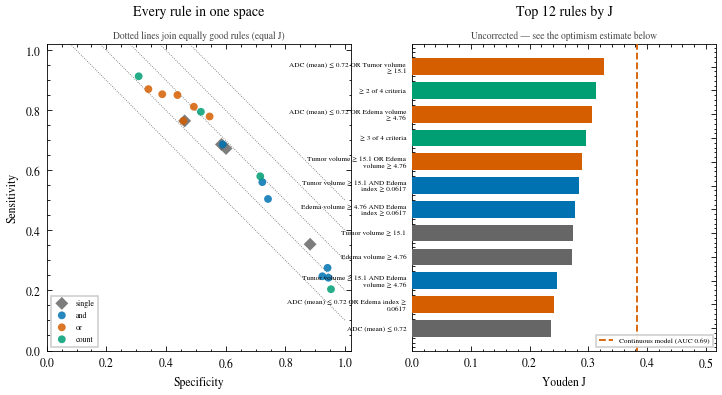

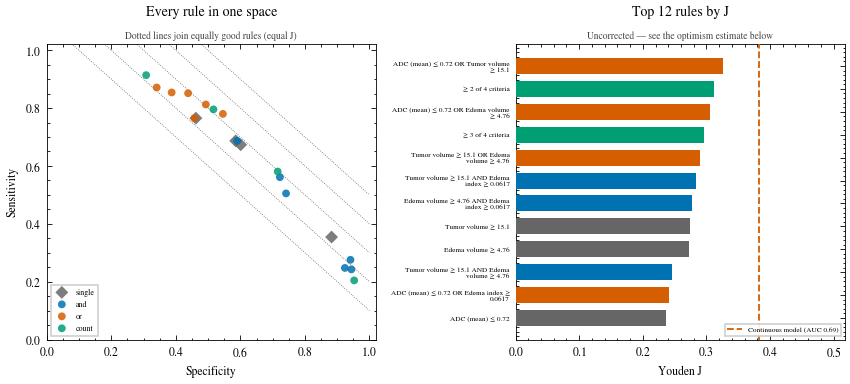

In [18]:
CONTINUOUS_BENCHMARK = cb.continuous_model_benchmark(
    df, METRICS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
)
art.figure(cb.combination_figure(RULE_MENU, benchmark=CONTINUOUS_BENCHMARK),
           "14_combination_space",
           caption="All rules in sensitivity–specificity space, with the continuous-model benchmark")

### The count score

**The most usable output in this notebook.** A radiologist counts how many of the criteria the tumor ticks and reads the risk off the bar — no logic gates, no ROC, no cut-point arithmetic at the workstation.

Wilson intervals are drawn because the end bars usually rest on few patients, and the `k/n` above each bar is there so nobody quotes a percentage without its denominator. A monotone staircase here is a genuine dose–response finding and is worth more poster space than any single cut-point.

,n_criteria_met,n,n_high_grade,risk,risk_lo,risk_hi
0,0,73,8,0.110,0.057,0.202
1,1,55,11,0.200,0.116,0.324
2,2,62,20,0.323,0.220,0.446
3,3,85,35,0.412,0.313,0.518
4,4,29,19,0.655,0.473,0.801


💾 output/thresholds/tables/15_count_score.csv — 5 rows


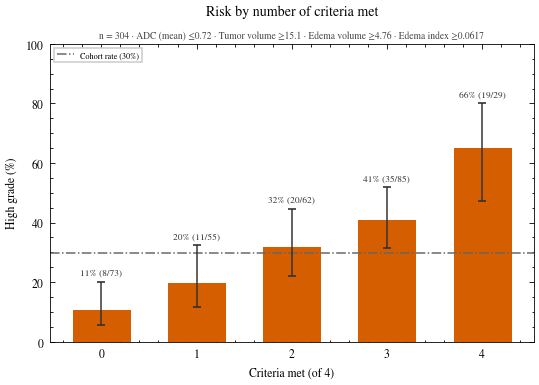

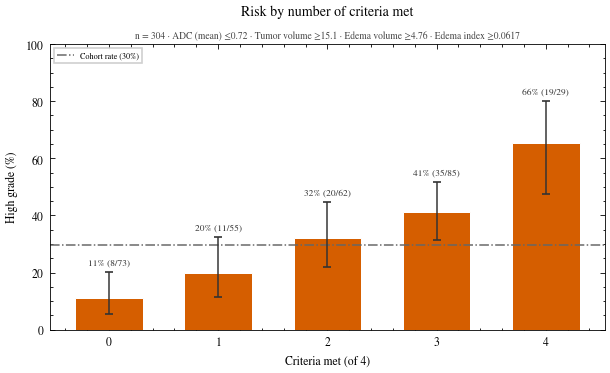

In [19]:
COUNT_TABLE = cb.count_score_table(df, CUTPOINTS, TARGET)
art.table(COUNT_TABLE, "15_count_score",
          caption="Observed high-grade rate by number of criteria met")

art.figure(
    cb.count_score_figure(COUNT_TABLE, cutpoints=CUTPOINTS,
                          prevalence=float(df[TARGET].astype("boolean").mean())),
    "16_count_score",
    caption="Risk by number of criteria met",
)

### The verdict on combining

Everything needed to answer "does the combination help?" in one table.

Read it in this order:

1. `best_single_J` vs `best_rule_J` — the raw improvement.
2. `best_rule_J_corrected` — what survives selection optimism. Compare **this** with `best_single_J`.
3. `winner_stability` — how often that rule actually wins. Low means the ranking is noise.
4. `continuous_J_equivalent` — the uncut model. If it beats everything, say so.

In [20]:
BEST_RULE = cb.bootstrap_best_rule(
    df, CUTPOINTS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
)
# The same optimism procedure, restricted to the four singles. Without it the
# comparison is a corrected combination against an uncorrected single, and the
# whole of the single's own selection optimism is credited to the combination.
BEST_SINGLE = cb.bootstrap_best_rule(
    df, CUTPOINTS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
    kinds=("single",),
)
auc_corrected = CONTINUOUS_BENCHMARK["AUC_corrected"]

COMBINATION_VERDICT = pd.DataFrame([{
    "best_single_rule": BEST_SINGLE["best_rule"],
    "best_single_J": BEST_SINGLE["J_apparent"],
    "best_single_J_corrected": BEST_SINGLE["J_corrected"],
    "best_single_selection_optimism": BEST_SINGLE["optimism"],
    "best_single_stability": BEST_SINGLE["winner_stability"],
    "best_rule": BEST_RULE["best_rule"],
    "best_rule_J": BEST_RULE["J_apparent"],
    "best_rule_J_corrected": BEST_RULE["J_corrected"],
    "selection_optimism": BEST_RULE["optimism"],
    "winner_stability": BEST_RULE["winner_stability"],
    "gain_apparent": BEST_RULE["J_apparent"] - BEST_SINGLE["J_apparent"],
    # Corrected against corrected — the only like-for-like comparison.
    "gain_vs_best_single": BEST_RULE["J_corrected"] - BEST_SINGLE["J_corrected"],
    "continuous_AUC_corrected": auc_corrected,
    "continuous_J_equivalent": 2.0 * (auc_corrected - 0.5),
    "n_used_continuous": CONTINUOUS_BENCHMARK["n_used"],
}])
art.table(COMBINATION_VERDICT, "17_combination_verdict",
          caption="Does combining cut-points beat the best single one?")

,best_single_rule,best_single_J,best_single_J_corrected,best_single_selection_optimism,best_single_stability,best_rule,best_rule_J,best_rule_J_corrected,selection_optimism,winner_stability,gain_apparent,gain_vs_best_single,continuous_AUC_corrected,continuous_J_equivalent,n_used_continuous
0,Tumor volume ≥ 15.1,0.274,0.232,0.042,0.408,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,0.326,0.282,0.044,0.4,0.052,0.05,0.69,0.383,304


💾 output/thresholds/tables/17_combination_verdict.csv — 1 rows


,best_single_rule,best_single_J,best_single_J_corrected,best_single_selection_optimism,best_single_stability,best_rule,best_rule_J,best_rule_J_corrected,selection_optimism,winner_stability,gain_apparent,gain_vs_best_single,continuous_AUC_corrected,continuous_J_equivalent,n_used_continuous
0,Tumor volume ≥ 15.1,0.274145,0.231926,0.042218,0.408,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,0.325872,0.282043,0.043829,0.4,0.051727,0.050117,0.691701,0.383401,304


In [21]:
gain = float(COMBINATION_VERDICT["gain_vs_best_single"].iloc[0])
single_corr = float(COMBINATION_VERDICT["best_single_J_corrected"].iloc[0])
stability = float(COMBINATION_VERDICT["winner_stability"].iloc[0])
cont_equiv = float(COMBINATION_VERDICT["continuous_J_equivalent"].iloc[0])
best_corr = float(COMBINATION_VERDICT["best_rule_J_corrected"].iloc[0])

verdict = (
    f"Best combination ({BEST_RULE['best_rule']}) reaches corrected J {best_corr:.3f} "
    f"against {single_corr:.3f} for the best single criterion corrected the same way, "
    f"a gain of {gain:+.3f}; the same rule won in {stability * 100:.0f}% of resamples."
)
if cont_equiv > best_corr:
    verdict += (
        f" The uncut continuous model is still better (J-equivalent {cont_equiv:.2f} "
        f"vs {best_corr:.2f}) — dichotomising cost more than combining gained."
    )
print(("🎯 " if gain > 0.05 and stability > 0.5 else "➖ ") + verdict)
art.note(verdict)

➖ Best combination (ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1) reaches corrected J 0.282 against 0.232 for the best single criterion corrected the same way, a gain of +0.050; the same rule won in 40% of resamples. The uncut continuous model is still better (J-equivalent 0.38 vs 0.28) — dichotomising cost more than combining gained.


### The same comparison on one denominator

Every rule above was scored on its own complete cases, so the denominators differ: an `OR`
needs one of the two measurements, an `AND` needs both, a single needs one. On this cohort
that is **n = 318** for the winning `OR`, **329** for tumour volume alone and **309** for
ADC alone. A Youden J compared across non-identical patient sets is not a comparison — part
of any apparent difference is the difference between the groups of patients.

So the whole head-to-head is re-run on the patients who have **all four** measurements.
Singles, `AND`/`OR`, count and the uncut model then share one denominator, and the only
thing that changed is the patient set: the cut-points stay frozen at the values §05 chose.

**This is the primary comparison.** The table above stays as the *all available data*
version — more patients per row, but not comparable across rows.

Shared-denominator cohort: 304 of 352 patients (93 high grade)


,rule_label,kind,n_criteria,members,n_used,TP,FP,FN,TN,sensitivity,sensitivity_lo,sensitivity_hi,specificity,specificity_lo,specificity_hi,PPV,PPV_lo,PPV_hi,NPV,NPV_lo,NPV_hi,youden_J,accuracy,p,test,note,predictor,accuracy_lo,accuracy_hi,AUC
0,ADC (mean) ≤ 0.72,single,1,ADC (mean) ≤0.72,304,34,25,59,186,0.366,0.275,0.467,0.882,0.831,0.918,0.576,0.449,0.694,0.759,0.702,0.808,0.247,0.724,<0.001,chi2,,ADC (mean) ≤ 0.72,0.671,0.771,0.62
1,Tumor volume ≥ 15.1,single,1,Tumor volume ≥15.1,304,61,85,32,126,0.656,0.555,0.745,0.597,0.530,0.661,0.418,0.341,0.499,0.797,0.728,0.853,0.253,0.615,<0.001,chi2,,Tumor volume ≥ 15.1,0.559,0.668,0.63
2,Edema volume ≥ 4.76,single,1,Edema volume ≥4.76,304,65,93,28,118,0.699,0.599,0.783,0.559,0.492,0.625,0.411,0.338,0.489,0.808,0.737,0.864,0.258,0.602,<0.001,chi2,,Edema volume ≥ 4.76,0.546,0.655,0.63
3,Edema index ≥ 0.0617,single,1,Edema index ≥0.0617,304,72,115,21,96,0.774,0.679,0.847,0.455,0.389,0.522,0.385,0.318,0.456,0.821,0.741,0.880,0.229,0.553,<0.001,chi2,,Edema index ≥ 0.0617,0.496,0.608,0.61
4,ADC (mean) ≤ 0.72 AND Tumor volume ≥ 15.1,and,2,ADC (mean) ≤0.72 + Tumor volume ≥15.1,304,24,17,69,194,0.258,0.180,0.355,0.919,0.875,0.949,0.585,0.434,0.722,0.738,0.681,0.787,0.177,0.717,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Tumor volume ≥ 15.1,0.664,0.765,0.59
5,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,or,2,ADC (mean) ≤0.72 + Tumor volume ≥15.1,304,71,93,22,118,0.763,0.668,0.838,0.559,0.492,0.625,0.433,0.359,0.509,0.843,0.774,0.894,0.323,0.622,<0.001,chi2,,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,0.566,0.674,0.66
6,ADC (mean) ≤ 0.72 AND Edema volume ≥ 4.76,and,2,ADC (mean) ≤0.72 + Edema volume ≥4.76,304,24,13,69,198,0.258,0.180,0.355,0.938,0.897,0.964,0.649,0.488,0.782,0.742,0.686,0.790,0.196,0.730,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Edema volume ≥ 4.76,0.678,0.777,0.60
7,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,or,2,ADC (mean) ≤0.72 + Edema volume ≥4.76,304,75,105,18,106,0.806,0.715,0.874,0.502,0.435,0.569,0.417,0.347,0.490,0.855,0.782,0.906,0.309,0.595,<0.001,chi2,,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,0.539,0.649,0.65
8,ADC (mean) ≤ 0.72 AND Edema index ≥ 0.0617,and,2,ADC (mean) ≤0.72 + Edema index ≥0.0617,304,27,13,66,198,0.290,0.208,0.389,0.938,0.897,0.964,0.675,0.520,0.799,0.750,0.694,0.798,0.229,0.740,<0.001,chi2,,ADC (mean) ≤ 0.72 AND Edema index ≥ 0.0617,0.688,0.786,0.61
9,ADC (mean) ≤ 0.72 OR Edema index ≥ 0.0617,or,2,ADC (mean) ≤0.72 + Edema index ≥0.0617,304,79,127,14,84,0.849,0.763,0.908,0.398,0.334,0.465,0.383,0.320,0.451,0.857,0.774,0.913,0.248,0.536,<0.001,chi2,,ADC (mean) ≤ 0.72 OR Edema index ≥ 0.0617,0.480,0.591,0.62


💾 output/thresholds/tables/30_shared_combination_menu.csv — 20 rows


,Rule,Type,n,Sens (95% CI),Spec (95% CI),PPV (95% CI),NPV (95% CI),TP/FP/FN/TN,J
5,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,or,304,76% (67–84),56% (49–62),43% (36–51),84% (77–89),71/93/22/118,0.32
17,≥ 2 of 4 criteria,count,304,80% (70–87),52% (45–58),42% (35–49),85% (78–90),74/102/19/109,0.31
7,ADC (mean) ≤ 0.72 OR Edema volume ≥ 4.76,or,304,81% (71–87),50% (44–57),42% (35–49),85% (78–91),75/105/18/106,0.31
18,≥ 3 of 4 criteria,count,304,58% (48–68),72% (65–77),47% (38–56),79% (73–85),54/60/39/151,0.30
11,Tumor volume ≥ 15.1 OR Edema volume ≥ 4.76,or,304,85% (76–91),43% (37–50),40% (33–47),87% (79–92),79/120/14/91,0.28
12,Tumor volume ≥ 15.1 AND Edema index ≥ 0.0617,and,304,56% (46–66),72% (66–78),47% (38–56),79% (72–84),52/59/41/152,0.28
14,Edema volume ≥ 4.76 AND Edema index ≥ 0.0617,and,304,70% (60–78),56% (50–63),41% (34–49),81% (74–86),65/92/28/119,0.26
2,Edema volume ≥ 4.76,single,304,70% (60–78),56% (49–62),41% (34–49),81% (74–86),65/93/28/118,0.26
1,Tumor volume ≥ 15.1,single,304,66% (55–74),60% (53–66),42% (34–50),80% (73–85),61/85/32/126,0.25
9,ADC (mean) ≤ 0.72 OR Edema index ≥ 0.0617,or,304,85% (76–91),40% (33–47),38% (32–45),86% (77–91),79/127/14/84,0.25


💾 output/thresholds/tables/31_shared_combination_reading_view.csv — 20 rows


,cohort,n_used,best_single_rule,best_single_J,best_single_J_corrected,best_single_selection_optimism,best_single_stability,best_rule,best_rule_J,best_rule_J_corrected,selection_optimism,winner_stability,gain_apparent,gain_vs_best_single,continuous_AUC_corrected,continuous_J_equivalent,n_used_continuous
0,shared denominator (all four measured),304,Edema volume ≥ 4.76,0.258,0.212,0.046,0.32,ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1,0.323,0.281,0.042,0.396,0.065,0.069,0.69,0.383,304


💾 output/thresholds/tables/32_shared_combination_verdict.csv — 1 rows


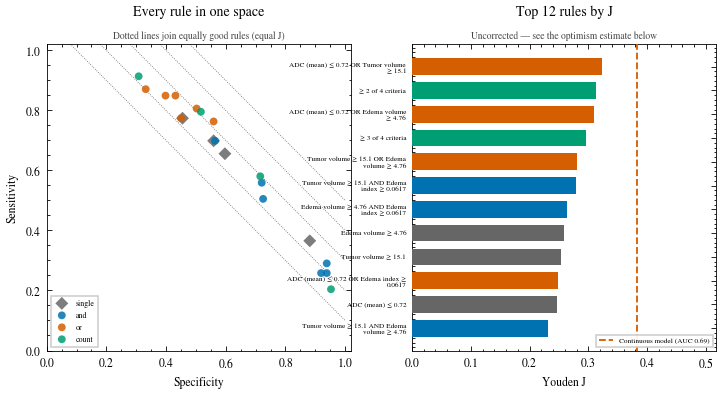

➖ Shared denominator (304 patients, every rule on the same people): best single becomes Edema volume ≥ 4.76 (corrected J 0.212); best combination ADC (mean) ≤ 0.72 OR Tumor volume ≥ 15.1 (corrected J 0.281), gain +0.069, stable in 40% of resamples; uncut model J-equivalent 0.38. Reading: the combination now clears the effect-size bar (gain > 0.05) but not the stability one: the winner holds in 40% of resamples, so which combination is best is still mostly noise. The negative conclusion survives, on stability rather than on effect size.


In [22]:
SHARED = cb.shared_cohort(df, CUTPOINTS, TARGET)
print(f"Shared-denominator cohort: {len(SHARED)} of {len(df)} patients "
      f"({SHARED[TARGET].astype('boolean').sum()} high grade)")

SHARED_MENU = cb.full_rule_menu(SHARED, CUTPOINTS, TARGET)
art.table(SHARED_MENU, "30_shared_combination_menu",
          caption=f"Every rule, all scored on the same {len(SHARED)} patients")
art.table(cb.combination_reading_view(SHARED_MENU), "31_shared_combination_reading_view",
          formatted=False, caption="Shared-denominator rules ranked by Youden J")

SHARED_BENCHMARK = cb.continuous_model_benchmark(
    SHARED, METRICS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
)
SHARED_BEST_RULE = cb.bootstrap_best_rule(
    SHARED, CUTPOINTS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
)
SHARED_BEST_SINGLE = cb.bootstrap_best_rule(
    SHARED, CUTPOINTS, TARGET, n_boot=N_BOOTSTRAP_CURVE, seed=BOOTSTRAP_SEED,
    kinds=("single",),
)
shared_auc = SHARED_BENCHMARK["AUC_corrected"]

SHARED_VERDICT = pd.DataFrame([{
    "cohort": "shared denominator (all four measured)",
    "n_used": len(SHARED),
    "best_single_rule": SHARED_BEST_SINGLE["best_rule"],
    "best_single_J": SHARED_BEST_SINGLE["J_apparent"],
    "best_single_J_corrected": SHARED_BEST_SINGLE["J_corrected"],
    "best_single_selection_optimism": SHARED_BEST_SINGLE["optimism"],
    "best_single_stability": SHARED_BEST_SINGLE["winner_stability"],
    "best_rule": SHARED_BEST_RULE["best_rule"],
    "best_rule_J": SHARED_BEST_RULE["J_apparent"],
    "best_rule_J_corrected": SHARED_BEST_RULE["J_corrected"],
    "selection_optimism": SHARED_BEST_RULE["optimism"],
    "winner_stability": SHARED_BEST_RULE["winner_stability"],
    "gain_apparent": SHARED_BEST_RULE["J_apparent"] - SHARED_BEST_SINGLE["J_apparent"],
    "gain_vs_best_single": SHARED_BEST_RULE["J_corrected"] - SHARED_BEST_SINGLE["J_corrected"],
    "continuous_AUC_corrected": shared_auc,
    "continuous_J_equivalent": 2.0 * (shared_auc - 0.5),
    "n_used_continuous": SHARED_BENCHMARK["n_used"],
}])
art.table(SHARED_VERDICT, "32_shared_combination_verdict",
          caption="Does combining help, with every rule on the same patients?")

art.figure(cb.combination_figure(SHARED_MENU, benchmark=SHARED_BENCHMARK),
           "33_shared_combination_space",
           caption=f"All rules on the same {len(SHARED)} patients, with the uncut benchmark")

# 🟧 The two bars a combination has to clear to count as helping. Both were
#    fixed before the shared-denominator run; neither is moved to fit it.
GAIN_BAR, STABILITY_BAR = 0.05, 0.50

shared_gain = float(SHARED_VERDICT["gain_vs_best_single"].iloc[0])
shared_stability = float(SHARED_VERDICT["winner_stability"].iloc[0])
clears_gain = shared_gain > GAIN_BAR
clears_stability = shared_stability > STABILITY_BAR

if clears_gain and clears_stability:
    reading = ("⚠️ the combination clears BOTH bars on one denominator — the earlier "
               "negative was partly a denominator artefact.")
elif clears_gain:
    reading = (f"the combination now clears the effect-size bar (gain > {GAIN_BAR}) but "
               f"not the stability one: the winner holds in {shared_stability * 100:.0f}% "
               f"of resamples, so which combination is best is still mostly noise. The "
               f"negative conclusion survives, on stability rather than on effect size.")
elif clears_stability:
    reading = ("the same rule wins reliably but the gain is too small to matter. The "
               "negative conclusion survives, on effect size rather than on stability.")
else:
    reading = "the combination clears neither bar. The negative conclusion survives intact."

shared_note = (
    f"Shared denominator ({len(SHARED)} patients, every rule on the same people): best "
    f"single becomes {SHARED_BEST_SINGLE['best_rule']} (corrected J "
    f"{SHARED_VERDICT['best_single_J_corrected'].iloc[0]:.3f}); best combination "
    f"{SHARED_BEST_RULE['best_rule']} (corrected J "
    f"{SHARED_VERDICT['best_rule_J_corrected'].iloc[0]:.3f}), gain {shared_gain:+.3f}, "
    f"stable in {shared_stability * 100:.0f}% of resamples; uncut model J-equivalent "
    f"{SHARED_VERDICT['continuous_J_equivalent'].iloc[0]:.2f}. Reading: {reading}"
)
print(("🎯 " if (clears_gain and clears_stability) else "➖ ") + shared_note)
art.note(shared_note)

---
# 07. Does any of it survive the missing data?

Everything above is **complete-case**: each analysis quietly drops the patients missing its own inputs (43 for ADC, 23 for tumor volume, 19 for edema volume — and 48 patients are missing at least one, so the count score scores only 304 of 352).

If those patients differ from the ones who kept their measurement, every answer above is shifted, and **no amount of bootstrapping will reveal it** — the bootstrap resamples the patients who are already there.

So all three analyses are re-derived on each of the m = 20 R MICE draws. Two different uncertainties then sit side by side:

| Source | Measured by | Question it answers |
|---|---|---|
| **Sampling** | bootstrap CI (§04–06) | would a different ~350 patients change the answer? |
| **Missing data** | spread across the m draws | would knowing the missing values change it? |

All three source metrics were imputed by predictive mean matching, and `high_grade` is complete, so every draw has all 352 patients and the outcome never varies between draws. The edema index is recomputed *inside* each draw from that draw's own components.

⚠️ **This is a stability check, not Rubin pooling.** Rubin's rules combine estimates with an approximately normal sampling distribution and a within-imputation variance; a cut-point picked by maximising `J` over hundreds of candidates has neither. Averaging the 20 cut-points is a reasonable point summary and the spread is a legitimate statement about how much the missing data matter — but it is *between-imputation variance only*, so never present it as a confidence interval. For a paper, quote the wider of the two spreads and describe it in words.

In [23]:
MICE_DRAWS = st.load_imputed_draws(OUTPUT_ROOT, derive=derive_edema_index)
M_DRAWS = len(MICE_DRAWS)
print(f"Loaded {M_DRAWS} imputed draw(s) — {IMPUTATION_METHOD}")
if M_DRAWS < 2:
    print("⚠️ Only one frame: this is single imputation, so the spread below is not meaningful.")

Loaded 20 imputed draw(s) — mice


## 07a. Cut-points across the draws

`cutoff_mean` is the average over the m draws — the number to quote if you want one cut-point that used all 352 patients.

**Watch for `cutoff_mean` and `cutoff_median` disagreeing.** That is the signature of a flat `J` plateau: the maximum hops between two local peaks from draw to draw, and the mean lands in the empty gap between them where no single draw ever pointed. When they disagree, neither is a cut-point — the finding is that the metric has no stable one.

`sens_at_mean` / `spec_at_mean` apply the **single averaged cut-point** back to every draw. That is what the cut-point would actually do in practice, and it is always slightly worse than the per-draw optimum, each of which was chosen with hindsight on its own draw.

In [24]:
DRAW_TABLE = st.draw_cutoffs(MICE_DRAWS, METRICS, TARGET)
STABILITY_TABLE = st.imputation_stability(
    DRAW_TABLE, MICE_DRAWS, METRICS, TARGET, THRESHOLD_TABLE,
)
art.table(STABILITY_TABLE, "18_imputation_stability",
          caption="Across-draw cut-point summary next to the complete-case value")

art.table(st.stability_reading_view(STABILITY_TABLE), "19_imputation_stability_reading_view",
          formatted=False, caption="Complete-case vs MICE cut-points with both spreads")

,metric,column,rule,operator,m_draws,cutoff_mean,cutoff_median,cutoff_sd,cutoff_min,cutoff_max,cutoff_cv,sens_mean,spec_mean,J_mean,AUC_mean,sens_at_mean,spec_at_mean,cutoff_complete_case,cutoff_boot_lo,cutoff_boot_hi,n_complete_case,shift_vs_complete_case
0,ADC (mean),adc_value,closest_01,≤,20,0.79,0.79,0.01,0.76,0.84,0.02,0.53,0.65,0.17,0.63,0.49,0.68,0.790,0.730,0.848,309,-0.001
1,ADC (mean),adc_value,equal_sens_spec,≤,20,0.81,0.81,0.00,0.81,0.82,0.00,0.57,0.57,0.14,0.63,0.56,0.57,0.810,0.790,0.830,309,0.003
2,ADC (mean),adc_value,sens_ge_90,≤,20,1.01,1.00,0.02,1.00,1.05,0.02,0.91,0.15,0.06,0.63,0.90,0.15,1.000,0.920,1.150,309,0.012
3,ADC (mean),adc_value,spec_ge_90,≤,20,0.70,0.70,0.00,0.69,0.71,0.01,0.27,0.91,0.18,0.63,0.27,0.91,0.700,0.670,0.720,309,0.001
4,ADC (mean),adc_value,youden,≤,20,0.72,0.72,0.00,0.72,0.73,0.01,0.36,0.87,0.23,0.63,0.35,0.88,0.720,0.690,0.850,309,0.002
5,Edema index,edema_index,closest_01,≥,20,0.15,0.17,0.04,0.06,0.17,0.26,0.69,0.53,0.21,0.58,0.68,0.51,0.167,0.062,0.599,323,-0.016
6,Edema index,edema_index,equal_sens_spec,≥,20,0.28,0.29,0.01,0.26,0.29,0.05,0.57,0.57,0.14,0.58,0.57,0.58,0.339,0.191,0.493,323,-0.062
7,Edema index,edema_index,spec_ge_90,≥,20,4.00,3.89,0.29,3.70,4.68,0.07,0.05,0.91,-0.04,0.58,0.04,0.91,3.895,3.129,13.237,323,0.108
8,Edema index,edema_index,youden,≥,20,0.06,0.06,0.01,0.02,0.06,0.17,0.76,0.47,0.23,0.58,0.75,0.47,0.062,0.043,0.175,323,-0.004
9,Edema volume,edema_volume_cm3,closest_01,≥,20,4.80,4.80,0.01,4.76,4.80,0.00,0.68,0.59,0.26,0.63,0.68,0.59,4.800,3.800,12.200,333,-0.004


💾 output/thresholds/tables/18_imputation_stability.csv — 18 rows


,Metric,Rule,Complete-case,Bootstrap 95%,MICE mean (m=20),MICE median,MICE SD,MICE range,Sens @ mean cut,Spec @ mean cut
0,ADC (mean),closest_01,≤0.79,0.73–0.848,≤0.789,≤0.79,0.0147,0.76–0.838,49%,68%
1,ADC (mean),equal_sens_spec,≤0.81,0.79–0.83,≤0.813,≤0.815,0.00294,0.81–0.82,56%,57%
2,ADC (mean),sens_ge_90,≤1,0.92–1.15,≤1.01,≤1,0.0197,1–1.05,90%,15%
3,ADC (mean),spec_ge_90,≤0.7,0.67–0.72,≤0.701,≤0.7,0.00447,0.69–0.71,27%,91%
4,ADC (mean),youden,≤0.72,0.69–0.85,≤0.722,≤0.72,0.0041,0.72–0.73,35%,88%
5,Edema index,closest_01,≥0.167,0.0617–0.599,≥0.151,≥0.167,0.0387,0.0617–0.167,68%,51%
6,Edema index,equal_sens_spec,≥0.339,0.191–0.493,≥0.277,≥0.286,0.014,0.256–0.286,57%,58%
7,Edema index,spec_ge_90,≥3.89,3.13–13.2,≥4,≥3.89,0.295,3.7–4.68,4%,91%
8,Edema index,youden,≥0.0617,0.0433–0.175,≥0.0577,≥0.0617,0.00981,0.0211–0.0617,75%,47%
9,Edema volume,closest_01,≥4.8,3.8–12.2,≥4.8,≥4.8,0.0123,4.76–4.8,68%,59%


💾 output/thresholds/tables/19_imputation_stability_reading_view.csv — 18 rows


,Metric,Rule,Complete-case,Bootstrap 95%,MICE mean (m=20),MICE median,MICE SD,MICE range,Sens @ mean cut,Spec @ mean cut
0,ADC (mean),closest_01,≤0.79,0.73–0.848,≤0.789,≤0.79,0.0147,0.76–0.838,49%,68%
1,ADC (mean),equal_sens_spec,≤0.81,0.79–0.83,≤0.813,≤0.815,0.00294,0.81–0.82,56%,57%
2,ADC (mean),sens_ge_90,≤1,0.92–1.15,≤1.01,≤1,0.0197,1–1.05,90%,15%
3,ADC (mean),spec_ge_90,≤0.7,0.67–0.72,≤0.701,≤0.7,0.00447,0.69–0.71,27%,91%
4,ADC (mean),youden,≤0.72,0.69–0.85,≤0.722,≤0.72,0.0041,0.72–0.73,35%,88%
5,Edema index,closest_01,≥0.167,0.0617–0.599,≥0.151,≥0.167,0.0387,0.0617–0.167,68%,51%
6,Edema index,equal_sens_spec,≥0.339,0.191–0.493,≥0.277,≥0.286,0.014,0.256–0.286,57%,58%
7,Edema index,spec_ge_90,≥3.89,3.13–13.2,≥4,≥3.89,0.295,3.7–4.68,4%,91%
8,Edema index,youden,≥0.0617,0.0433–0.175,≥0.0577,≥0.0617,0.00981,0.0211–0.0617,75%,47%
9,Edema volume,closest_01,≥4.8,3.8–12.2,≥4.8,≥4.8,0.0123,4.76–4.8,68%,59%


### The two instabilities, drawn

Per metric, for the Youden rule: the shaded band is the **bootstrap** interval from the complete cases (sampling noise), the dots are the **20 MICE draws** (missing-data uncertainty), and the solid line is the complete-case cut-point you would otherwise have reported.

Read it as a ratio. Dots tightly clustered inside a wide band → missingness is not your problem, sample size is. Dots scattered across or beyond the band → the cut-point depends on which values got imputed, and a complete-case number quoted alone would be overconfident.

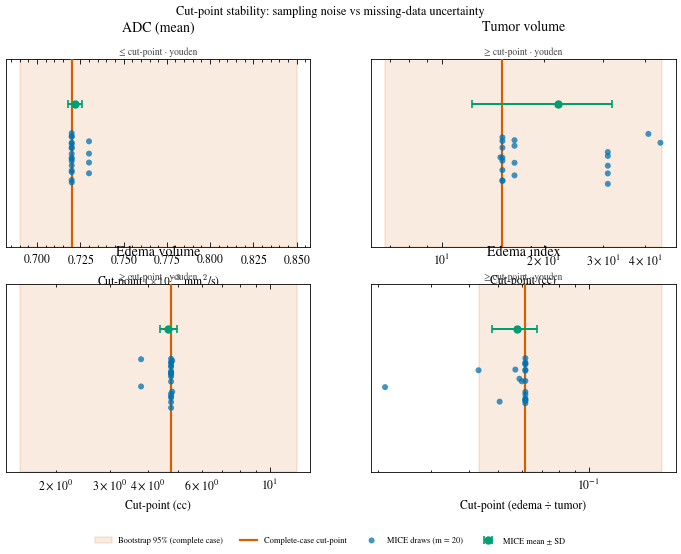

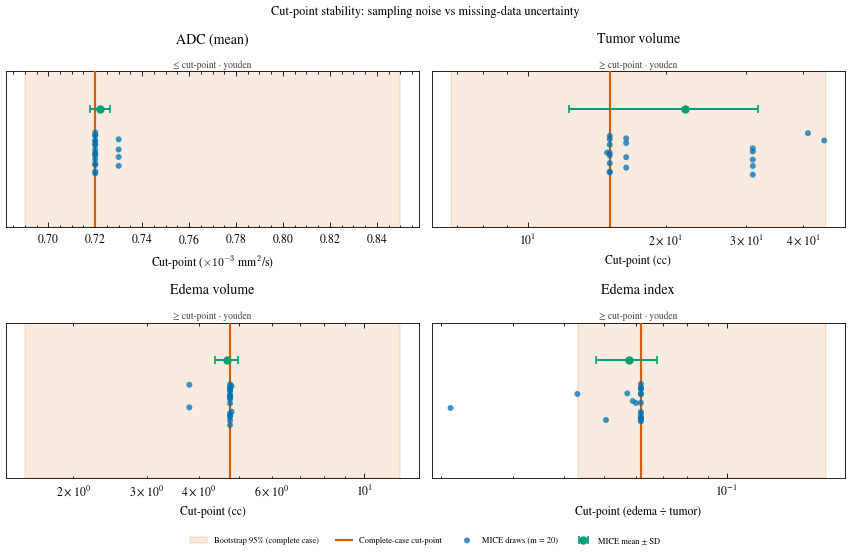

In [25]:
art.figure(st.stability_figure(DRAW_TABLE, STABILITY_TABLE, METRICS, rule="youden"),
           "20_stability_youden",
           caption="Sampling noise vs missing-data uncertainty in the Youden cut-point")

### Which number do I actually use?

Only three of the columns above are **candidate cut-points**; the other three are **error bars**. You are not choosing among all six.

| Candidate | What it is |
|---|---|
| `Complete-case` | The cut-point from patients who actually had the measurement. Real data, fewer patients. |
| `MICE mean` | Run the analysis on all m filled-in datasets, average the m cut-points. All patients, some values guessed. |
| `MICE median` | Same m cut-points, middle one instead of the average. |

| Spread | What it answers |
|---|---|
| `Bootstrap 95%` | "If I'd recruited a different ~350 patients, how much would this move?" → **sample-size noise** |
| `MICE SD` | "How much does it move depending on what the missing values were?" → **missing-data noise** |
| `MICE range` | Same question, min-to-max. Catches bimodality that an SD hides. |

**How to choose — mostly a check, not a judgement call**

1. **Do the three candidates agree?** If yes, report the complete-case one; it is the simplest to explain.
2. **Do mean and median disagree?** Then the cut-point is hopping between values across draws. That gap **is** the finding — don't pick a number, report that no stable cut-point exists.
3. **Then read the spreads to decide how confidently to phrase it.** A bootstrap interval spanning an order of magnitude means the defensible sentence is "no stable cut-point in this cohort".

**Where the real trade-off lives** — not in this table, but in the *rule* (§05). Youden vs `spec_ge_90` vs `sens_ge_90` is a genuine clinical choice: you are trading missed high-grade tumors against false alarms, and only a clinician can say which costs more. Complete-case vs MICE is *not* a trade-off — it is a robustness check, and it has a right answer.

## 07b. Is the *"šķēre"* reproducible?

The headline column is **`knee_rate`**: the fraction of the 20 imputed datasets in which a non-linear risk curve with an interior steepest point was found *at all*.

- Near 1 → the threshold is a property of the data.
- Near 0 → it was a property of which patients happened to have that scan, and a complete-case threshold quoted alone would be an artefact.

An empty panel in the figure below is a result, not a bug: in those draws there was no *"šķēre"* to locate.

,metric,column,m_draws,nonlinear_rate,knee_rate,median_nonlinearity_p,AUC_mean,steepest_median,steepest_min,steepest_max,risk_30_median,risk_30_min,risk_30_max,risk_30_reached_rate,risk_50_median,risk_50_min,risk_50_max,risk_50_reached_rate
0,ADC (mean),adc_value,20,0.85,0.6,0.016,0.63,0.66,0.63,0.67,0.79,0.78,0.80,1,0.65,0.62,0.67,1
1,Tumor volume,tumor_volume,20,0.90,0.9,0.035,0.68,12.49,12.08,12.75,20.10,19.63,20.57,1,70.03,63.39,75.07,1
2,Edema volume,edema_volume_cm3,20,1.00,1.0,0.011,0.63,3.44,2.87,4.01,10.15,9.56,11.11,1,,,,0
3,Edema index,edema_index,20,0.90,0.9,0.036,0.58,0.09,0.08,0.11,0.41,0.38,0.46,1,,,,0


💾 output/thresholds/tables/21_risk_curve_stability.csv — 4 rows


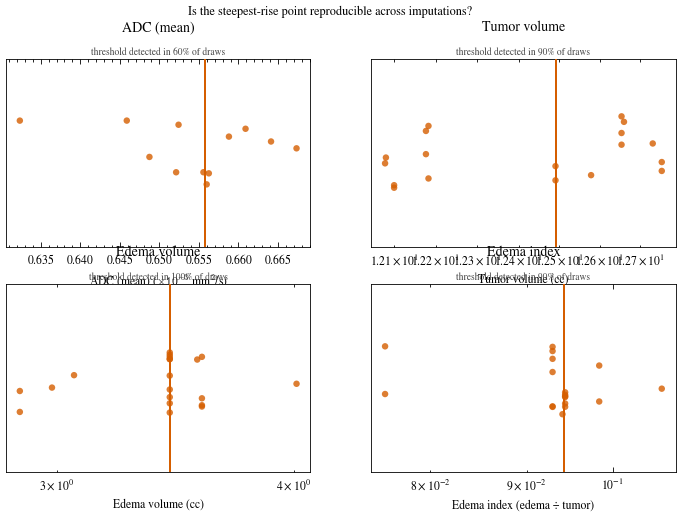

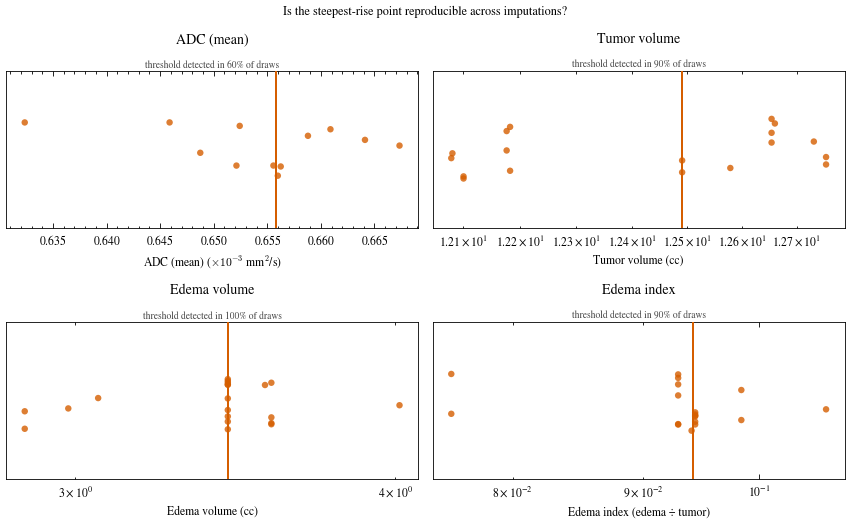

In [26]:
RISK_DRAWS = st.draw_risk_curves(MICE_DRAWS, METRICS, TARGET, risk_levels=RISK_LEVELS)
RISK_STABILITY = st.risk_curve_stability(RISK_DRAWS)
art.table(RISK_STABILITY, "21_risk_curve_stability",
          caption="How often each metric's threshold survives the imputation")

art.figure(st.knee_stability_figure(RISK_DRAWS, METRICS), "22_knee_stability",
           caption="Steepest-rise point across the MICE draws")

## 07c. The count score with every patient included

The complete-case count score drops anyone missing a single metric — 48 patients here, more than any individual metric loses. Inside a draw nothing is missing, so every patient gets a count.

`risk_min` / `risk_max` are the range across the 20 draws. A staircase that keeps its shape across all of them is a robust finding; one that only appears in the complete cases is not.

,n_criteria_met,n,n_high_grade,risk,risk_min,risk_max,risk_lo,risk_hi
0,0,89,10,0.109,0.09,0.12,0.059,0.190
1,1,66,14,0.206,0.18,0.24,0.126,0.319
2,2,71,22,0.305,0.29,0.32,0.210,0.420
3,3,95,40,0.417,0.40,0.44,0.323,0.517
4,4,31,20,0.652,0.61,0.69,0.477,0.794


💾 output/thresholds/tables/23_count_score_imputed.csv — 5 rows


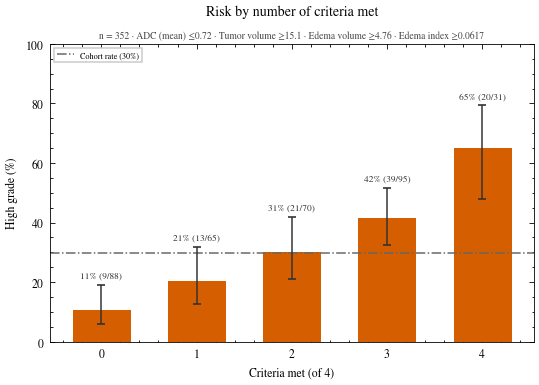

,rule_label,n_used,sensitivity,sens_min,sens_max,specificity,spec_min,spec_max,PPV,NPV,youden_J,J_min,J_max
0,≥ 1 of 4 criteria,352,0.908,0.90,0.92,0.321,0.31,0.33,0.362,0.891,0.229,0.21,0.26
1,≥ 2 of 4 criteria,352,0.779,0.76,0.79,0.532,0.52,0.54,0.414,0.850,0.311,0.28,0.33
2,≥ 3 of 4 criteria,352,0.573,0.55,0.59,0.731,0.72,0.74,0.475,0.801,0.304,0.28,0.32
3,≥ 4 of 4 criteria,352,0.195,0.18,0.22,0.956,0.95,0.96,0.652,0.736,0.151,0.13,0.17


💾 output/thresholds/tables/25_count_rules_imputed.csv — 4 rows


,rule_label,n_used,sensitivity,sens_min,sens_max,specificity,spec_min,spec_max,PPV,NPV,youden_J,J_min,J_max
0,≥ 1 of 4 criteria,352.0,0.908095,0.895238,0.923810,0.320648,0.307692,0.331984,0.362353,0.891400,0.228743,0.212454,0.255793
1,≥ 2 of 4 criteria,352.0,0.779048,0.761905,0.790476,0.531781,0.518219,0.538462,0.414288,0.849918,0.310829,0.284172,0.328938
2,≥ 3 of 4 criteria,352.0,0.573333,0.552381,0.590476,0.730972,0.720648,0.740891,0.475347,0.801204,0.304305,0.281126,0.323270
3,≥ 4 of 4 criteria,352.0,0.194762,0.180952,0.219048,0.955870,0.947368,0.959514,0.652331,0.736325,0.150632,0.132369,0.169038


In [27]:
COUNT_DRAWS = st.draw_count_scores(MICE_DRAWS, CUTPOINTS, TARGET)
art.table(COUNT_DRAWS, "23_count_score_imputed",
          caption=f"Count-score risk averaged over {M_DRAWS} MICE draws (all patients)")

art.figure(
    cb.count_score_figure(COUNT_DRAWS, cutpoints=CUTPOINTS,
                          prevalence=float(df[TARGET].astype("boolean").mean())),
    "24_count_score_imputed",
    caption=f"Risk by criteria met, averaged over {M_DRAWS} MICE draws",
)

art.table(st.draw_count_rules(MICE_DRAWS, CUTPOINTS, TARGET), "25_count_rules_imputed",
          caption='"≥ k criteria" rules scored inside every draw')

---
# 08. How strong is each threshold claim?

§04 answered *is there a threshold?* with one likelihood-ratio test per metric. A bare
**yes** is a weaker claim than it looks — and an easier one to attack. It rests on a
single p-value clearing 0.05, and it says nothing about whether the knee sits where the
patients are, whether it survives a change of fitting scale, or whether it is simply the
50%-risk crossing under a new name.

So the gate is replaced by **five criteria, fixed before any verdict was read off**, in
two families:

| # | Criterion | Family | Rule |
|---|---|---|---|
| 1 | Non-linearity | necessary | LRT p < 0.05 on the clinical scale |
| 2 | Knee interiority | necessary | ≥ 5% of patients on each side of the knee |
| 3 | Knee ≠ 50%-risk point | necessary | knee outside the bootstrap CI of the 50% crossing |
| 4 | Scale robustness | robustness | non-linear in clinical units **and** on the log scale |
| 5 | MICE reproducibility | robustness | knee found again in ≥ 80% of the imputed datasets |

*Necessary* means the claim is not supportable if it fails; *robustness* means the claim
survives a choice we were not forced into. They map onto four grades — **strong**,
**moderate**, **fragile**, **weak** — with the binding criterion named in every cell.

Two further numbers sit next to the grade and deliberately **do not score it**: the width
of the knee's bootstrap interval and the metric's AUC. They say how precisely the knee is
pinned down and whether the metric carries signal at all, which five binary criteria
cannot see. Read them before quoting a grade.

Nothing is refitted here. Every input column already exists in §04's and §07b's tables, so
the grade can never disagree with the numbers it grades.

In [28]:
EVIDENCE = ev.threshold_evidence(
    RISK_TABLE, RISK_STABILITY,
    # Non-scoring context: the zero-inflation refit from §04. It does not move
    # the grade — it was not one of the five pre-specified criteria — but a
    # curvature that vanishes on the non-zero subset changes what the knee means.
    positive_risk_table=POSITIVE_RISK_TABLE,
    zero_share_table=ZERO_SHARE,
)

art.table(ev.criteria_table(), "27_evidence_criteria", formatted=False,
          caption="The five pre-specified criteria and the rule each applies")
art.table(EVIDENCE, "28_threshold_evidence",
          caption="Each metric scored on the five criteria, with its graded verdict")
art.table(ev.evidence_reading_view(EVIDENCE), "29_threshold_evidence_reading_view",
          formatted=False, caption="The graded verdict, in reading order")

MARK = {"strong": "🟩", "moderate": "🟨", "fragile": "🟧", "weak": "🟥"}
for _, row in EVIDENCE.iterrows():
    print(f"{MARK[row['verdict']]} {row['metric']}: {row['verdict_note']}")
    art.note(f"{row['metric']} — threshold evidence {row['verdict_note']}.")

,Criterion,Family,Source,Rule
0,Non-linearity,necessary,"Likelihood-ratio test, spline vs straight line...",p &lt; 0.05
1,Knee interiority,necessary,Percentile of patients below the steepest poin...,≥ 5% of patients on each side
2,Knee ≠ 50%-risk point,necessary,Bootstrap interval of the 50% risk crossing (s...,steepest point falls outside that interval
3,Scale robustness,robustness,<code>nonlinearity_p_log_scale</code> (section 3),non-linear on the clinical scale <b>and</b> on...
4,MICE reproducibility,robustness,<code>knee_rate</code> across the imputed data...,knee found again in ≥ 80% of draws


💾 output/thresholds/tables/27_evidence_criteria.csv — 5 rows


,metric,column,verdict,n_criteria_passed,n_criteria,limiting_criterion,failed_criteria,knee_ci_ratio,AUC,pct_zero,nonlinearity_p_nonzero_only,knee_found_nonzero_only,pass_nonlinearity,detail_nonlinearity,pass_interiority,detail_interiority,pass_distinct_from_50,detail_distinct_from_50,pass_scale_robust,detail_scale_robust,pass_mice_reproducible,detail_mice_reproducible,verdict_note,context_note
0,ADC (mean),adc_value,fragile,3,5,Knee ≠ 50%-risk point,Knee ≠ 50%-risk point; MICE reproducibility,1.132,0.63,,,,True,p = 0.009 on the clinical scale,True,7% of patients below the knee,False,knee 0.662 vs 50% crossing CI 0.598–0.716 — in...,True,log-scale p = 0.015,False,knee found in 60% of draws,fragile — Knee ≠ 50%-risk point fails (knee 0....,
1,Tumor volume,tumor_volume,moderate,4,5,Scale robustness,Scale robustness,1.713,0.68,,,,True,p = 0.021 on the clinical scale,True,47% of patients below the knee,True,knee 12.7 vs 50% crossing CI 32.5–102 — outsid...,False,log-scale p = 0.974,True,knee found in 90% of draws,moderate — Scale robustness fails (log-scale p...,
2,Edema volume,edema_volume_cm3,moderate,4,5,Scale robustness,Scale robustness,4.714,0.63,36.6,0.18,False,True,p = 0.007 on the clinical scale,True,48% of patients below the knee,True,"50% risk located in only 30% of resamples, so ...",False,log-scale p = 0.159,True,knee found in 100% of draws,moderate — Scale robustness fails (log-scale p...,36.6% of measured patients are exactly zero; r...
3,Edema index,edema_index,strong,5,5,,,3.617,0.58,35.0,0.675,False,True,p = 0.047 on the clinical scale,True,41% of patients below the knee,True,"50% risk located in only 5% of resamples, so t...",True,log-scale p = 0.002,True,knee found in 90% of draws,strong — all 5 criteria met,35.0% of measured patients are exactly zero; r...


💾 output/thresholds/tables/28_threshold_evidence.csv — 4 rows


,Metric,Evidence,Non-linearity,Knee interiority,Knee ≠ 50%-risk point,Scale robustness,MICE reproducibility,Criteria met,What limits it,Read alongside (does not score)
0,ADC (mean),fragile,pass — p = 0.009 on the clinical scale,pass — 7% of patients below the knee,fail — knee 0.662 vs 50% crossing CI 0.598–0.7...,pass — log-scale p = 0.015,fail — knee found in 60% of draws,3 of 5,Knee ≠ 50%-risk point,—
1,Tumor volume,moderate,pass — p = 0.021 on the clinical scale,pass — 47% of patients below the knee,pass — knee 12.7 vs 50% crossing CI 32.5–102 —...,fail — log-scale p = 0.974,pass — knee found in 90% of draws,4 of 5,Scale robustness,—
2,Edema volume,moderate,pass — p = 0.007 on the clinical scale,pass — 48% of patients below the knee,pass — 50% risk located in only 30% of resampl...,fail — log-scale p = 0.159,pass — knee found in 100% of draws,4 of 5,Scale robustness,36.6% of measured patients are exactly zero; r...
3,Edema index,strong,pass — p = 0.047 on the clinical scale,pass — 41% of patients below the knee,pass — 50% risk located in only 5% of resample...,pass — log-scale p = 0.002,pass — knee found in 90% of draws,5 of 5,—,35.0% of measured patients are exactly zero; r...


💾 output/thresholds/tables/29_threshold_evidence_reading_view.csv — 4 rows
🟧 ADC (mean): fragile — Knee ≠ 50%-risk point fails (knee 0.662 vs 50% crossing CI 0.598–0.716 — inside it); MICE reproducibility fails (knee found in 60% of draws)
🟨 Tumor volume: moderate — Scale robustness fails (log-scale p = 0.974)
🟨 Edema volume: moderate — Scale robustness fails (log-scale p = 0.159)
🟩 Edema index: strong — all 5 criteria met


---
# 09. Headline findings

One row per metric, pulling together everything above: does it discriminate, does it have a threshold, is that threshold reproducible, and what cut-point would you quote.

This is the table to write the results paragraph from.

In [29]:
def headline_rows() -> pd.DataFrame:
    risk = RISK_TABLE.set_index("column")
    risk_stab = RISK_STABILITY.set_index("column")
    stab = STABILITY_TABLE[STABILITY_TABLE["rule"] == "youden"].set_index("column")
    evid = EVIDENCE.set_index("column")
    youden = THRESHOLD_TABLE[THRESHOLD_TABLE["rule"] == "youden"].set_index("column")

    rows = []
    for metric in METRICS:
        col = metric.col
        r, y = risk.loc[col], youden.loc[col]
        s = stab.loc[col] if col in stab.index else None
        rs = risk_stab.loc[col] if col in risk_stab.index else None
        rows.append({
            "Metric": metric.label,
            "Unit": metric.prose_unit,
            "n": int(r["n"]),
            "AUC": round(float(r["AUC"]), 2),
            # Graded, not yes/no (§08). A bare "yes" hides the difference
            # between a knee sitting in the bulk of the cohort and one that is
            # the 50%-risk crossing renamed — and both used to print as "yes".
            "Threshold evidence": evid.loc[col, "verdict"],
            "What limits it": evid.loc[col, "limiting_criterion"] or "—",
            "Non-linearity p": ps.format_p(r["nonlinearity_p"]),
            "Steepest rise": ("—" if not r["knee_found"]
                              else f"{r['steepest_x']:.3g} ({r['steepest_lo']:.3g}–{r['steepest_hi']:.3g})"),
            "Reproducible (MICE)": ("" if rs is None
                                    else f"{rs['knee_rate'] * 100:.0f}% of draws"),
            "Risk 30% at": ("never" if pd.isna(r["risk_30_x"]) else f"{metric.op}{r['risk_30_x']:.3g}"),
            "Risk 50% at": ("never" if pd.isna(r["risk_50_x"]) else f"{metric.op}{r['risk_50_x']:.3g}"),
            "Youden cut-point": f"{metric.op}{y['cutoff']:.3g}",
            "Cut-point 95% CI": f"{y['cutoff_boot_lo']:.3g}–{y['cutoff_boot_hi']:.3g}",
            "Sens / Spec": f"{y['sensitivity'] * 100:.0f}% / {y['specificity'] * 100:.0f}%",
            "J (corr.)": round(float(y["youden_J_corrected"]), 2),
            "MICE cut-point": "" if s is None else f"{metric.op}{s['cutoff_mean']:.3g}",
            "Cut-point stable?": ("" if s is None else
                                  ("yes" if abs(s["cutoff_mean"] - s["cutoff_median"])
                                   <= 0.1 * abs(s["cutoff_median"]) else "no — mean ≠ median")),
        })
    return pd.DataFrame(rows)


HEADLINE = headline_rows()
art.table(HEADLINE, "26_headline_findings", formatted=False,
          caption="One row per metric: discrimination, threshold, reproducibility, cut-point")

,Metric,Unit,n,AUC,Threshold evidence,What limits it,Non-linearity p,Steepest rise,Reproducible (MICE),Risk 30% at,Risk 50% at,Youden cut-point,Cut-point 95% CI,Sens / Spec,J (corr.),MICE cut-point,Cut-point stable?
0,ADC (mean),×10⁻³ mm²/s,309,0.63,fragile,Knee ≠ 50%-risk point,= 0.009,0.662 (0.623–0.706),60% of draws,≤0.791,≤0.663,≤0.72,0.69–0.85,35% / 88%,0.21,≤0.722,yes
1,Tumor volume,cc,329,0.68,moderate,Scale robustness,= 0.021,12.7 (9.93–17),90% of draws,≥18.5,≥62.3,≥15.1,6.78–44.8,67% / 60%,0.23,≥22.1,no — mean ≠ median
2,Edema volume,cc,333,0.63,moderate,Scale robustness,= 0.007,3.51 (1.7–8),100% of draws,≥9.92,never,≥4.76,1.53–12.2,69% / 59%,0.25,≥4.67,yes
3,Edema index,,323,0.58,strong,—,= 0.047,0.0915 (0.0656–0.237),90% of draws,≥0.383,never,≥0.0617,0.0433–0.175,77% / 46%,0.21,≥0.0577,yes


💾 output/thresholds/tables/26_headline_findings.csv — 4 rows


,Metric,Unit,n,AUC,Threshold evidence,What limits it,Non-linearity p,Steepest rise,Reproducible (MICE),Risk 30% at,Risk 50% at,Youden cut-point,Cut-point 95% CI,Sens / Spec,J (corr.),MICE cut-point,Cut-point stable?
0,ADC (mean),×10⁻³ mm²/s,309,0.63,fragile,Knee ≠ 50%-risk point,= 0.009,0.662 (0.623–0.706),60% of draws,≤0.791,≤0.663,≤0.72,0.69–0.85,35% / 88%,0.21,≤0.722,yes
1,Tumor volume,cc,329,0.68,moderate,Scale robustness,= 0.021,12.7 (9.93–17),90% of draws,≥18.5,≥62.3,≥15.1,6.78–44.8,67% / 60%,0.23,≥22.1,no — mean ≠ median
2,Edema volume,cc,333,0.63,moderate,Scale robustness,= 0.007,3.51 (1.7–8),100% of draws,≥9.92,never,≥4.76,1.53–12.2,69% / 59%,0.25,≥4.67,yes
3,Edema index,,323,0.58,strong,—,= 0.047,0.0915 (0.0656–0.237),90% of draws,≥0.383,never,≥0.0617,0.0433–0.175,77% / 46%,0.21,≥0.0577,yes


### The sentences these numbers support

Templates, filled from the table above. Check every one against the figures before it goes anywhere near a manuscript — these are drafting aids, not conclusions.

In [30]:
for metric in METRICS:
    curve = CURVES[metric.col]
    row = RISK_TABLE.set_index("column").loc[metric.col]
    y = THRESHOLD_TABLE[
        (THRESHOLD_TABLE["column"] == metric.col) & (THRESHOLD_TABLE["rule"] == "youden")
    ].iloc[0]
    stab = RISK_STABILITY.set_index("column").loc[metric.col]

    unit = f" {metric.prose_unit}" if metric.prose_unit else ""
    p_text = f"likelihood-ratio test for non-linearity p {ps.format_p(row['nonlinearity_p'])}"

    grade = EVIDENCE.set_index("column").loc[metric.col]

    print(f"\n▪ {metric.label}")
    print(f"   Threshold evidence: {grade['verdict_note']}.")
    if curve.knee_found:
        print(f"   Risk of high-grade meningioma rose non-linearly with {metric.label} "
              f"({p_text}), with the steepest increase at {row['steepest_x']:.3g}{unit} "
              f"(95% CI {row['steepest_lo']:.3g}–{row['steepest_hi']:.3g}); this threshold was "
              f"reproduced in {stab['knee_rate'] * 100:.0f}% of {M_DRAWS} imputed datasets.")
    elif curve.nonlinear:
        # Curved, but still climbing (or already flat) where the data stop —
        # calling this "no evidence of non-linearity" would misreport the test.
        print(f"   The relationship between {metric.label} and risk of high-grade "
              f"meningioma was non-linear ({p_text}), but risk rose fastest at the edge "
              f"of the observed range, so no threshold could be located within it.")
    else:
        print(f"   Risk of high-grade meningioma increased monotonically with {metric.label} "
              f"with no evidence of a threshold effect ({p_text}).")
    if pd.notna(row["risk_50_x"]):
        print(f"   Predicted risk exceeded 50% at {metric.label} {metric.op} "
              f"{row['risk_50_x']:.3g}{unit}.")
    elif pd.notna(row["risk_30_x"]):
        print(f"   Predicted risk exceeded 30% at {metric.label} {metric.op} "
              f"{row['risk_30_x']:.3g}{unit} but never reached 50%.")
    print(f"   The optimal cut-point by Youden's index was {metric.op}{y['cutoff']:.3g} "
          f"(bootstrap 95% CI {y['cutoff_boot_lo']:.3g}–{y['cutoff_boot_hi']:.3g}), "
          f"sensitivity {y['sensitivity'] * 100:.0f}% "
          f"({y['sensitivity_lo'] * 100:.0f}–{y['sensitivity_hi'] * 100:.0f}), "
          f"specificity {y['specificity'] * 100:.0f}% "
          f"({y['specificity_lo'] * 100:.0f}–{y['specificity_hi'] * 100:.0f}); "
          f"optimism-corrected J {y['youden_J_corrected']:.2f}.")


▪ ADC (mean)
   Threshold evidence: fragile — Knee ≠ 50%-risk point fails (knee 0.662 vs 50% crossing CI 0.598–0.716 — inside it); MICE reproducibility fails (knee found in 60% of draws).
   Risk of high-grade meningioma rose non-linearly with ADC (mean) (likelihood-ratio test for non-linearity p = 0.009), with the steepest increase at 0.662 ×10⁻³ mm²/s (95% CI 0.623–0.706); this threshold was reproduced in 60% of 20 imputed datasets.
   Predicted risk exceeded 50% at ADC (mean) ≤ 0.663 ×10⁻³ mm²/s.
   The optimal cut-point by Youden's index was ≤0.72 (bootstrap 95% CI 0.69–0.85), sensitivity 35% (27–45), specificity 88% (83–92); optimism-corrected J 0.21.

▪ Tumor volume
   Threshold evidence: moderate — Scale robustness fails (log-scale p = 0.974).
   Risk of high-grade meningioma rose non-linearly with Tumor volume (likelihood-ratio test for non-linearity p = 0.021), with the steepest increase at 12.7 cc (95% CI 9.93–17); this threshold was reproduced in 90% of 20 imputed datasets.

---
# 10. Before any of this goes in a paper

- **Every data-derived cut-point here is optimistic.** Each rule takes a maximum over hundreds of candidates on the data it is then scored on. Report `youden_J_corrected` next to `youden_J`, or quote an external cut-point and only *validate* it here.
- **Check the interval before writing "the optimal threshold was X".** For a metric whose bootstrap interval spans an order of magnitude, the defensible sentence is that no stable cut-point exists in this cohort.
- **A threshold effect and an optimal cut-point are different claims.** §04 answers the first, §05 the second. Only report a *"šķēre"* where `knee_found` is true and `knee_rate` across the imputations is high; everywhere else, say risk rose steadily.
- **PPV and NPV are prevalence-bound.** This is a surgical series — about 30% high grade, far above the population rate. Sensitivity and specificity transfer to a screening population; PPV and NPV do not.
- **Two spreads, not one.** §04–06 are complete-case, so their bootstrap intervals cover sampling noise only. §07 adds the spread across the MICE draws, which covers the missing data. Quote the wider one, and never present the across-draw SD as a confidence interval — it is between-imputation variance, not a Rubin-pooled quantity.
- **Dichotomising loses information.** A cut-point is for the clinic; for the model, the continuous metric is strictly more informative. If §06 shows the continuous benchmark beating every cut rule, say so — it is a finding, and it is why the modelling notebook keeps `adc_value` continuous.
- **Multiplicity.** Four metrics × five rules × a dozen combination rules is a lot of looks at one outcome, and the p-values here are not corrected for any of it. Treat them as descriptive and lean on the intervals instead.
- **The edema volume is zero-inflated.** A quarter of this cohort has exactly no peritumoral edema. "No edema at all" behaves like a category, not a small number, and any threshold on that metric should be read with that in mind.

---
## 11. Build `threshold_report.html`

A self-contained HTML document assembled from the tables and figures this run just wrote — nothing is refitted, so the report and the CSVs can never disagree.

It is two things at once:

- **A step-by-step report** — each section states its question, the method in two sentences, the figure, and the answer.
- **A reference you can re-read before presenting** — §09 is the ESNR defence (the questions a commission asks, each with the number that answers it), §10 is every term in one line with what it was on this cohort.

Written for a radiologist, not a statistician. Regenerate it any time without re-running the analysis:

```bash
python heavy_machinery/threshold_phase/threshold_report.py --output-root output
```

In [31]:
import threshold_report as trep

# 🟧 Goes on the title page.
REPORT_AUTHOR = ""

report_cfg = trep.ThresholdReportConfig(
    output_root=OUTPUT_ROOT,
    author=REPORT_AUTHOR,
)
report_data = trep.load_report_data(report_cfg)
report_path = trep.write_html(
    trep.build_report(report_cfg, report_data), report_cfg.default_out,
)
print(f"📄 {report_path}")
for warning in report_data.warnings:
    print(f"   ⚠️ {warning}")

📄 /Users/andriszaguzovs/TheLibraryOfCode/meningioma-atypier/output/thresholds/threshold_report.html


## 12. Export receipt

Everything this run wrote, plus a `manifest.json` recording the settings that produced it. Files left over from a previous configuration are listed rather than deleted — a leftover is worth looking at before it is thrown away.

In [32]:
manifest_path = art.write_manifest()
receipt = art.written()
print(f"{len(receipt)} artifacts under {art.root}")
if manifest_path:
    print(f"📄 {manifest_path}")

stale = art.stale_files()
if stale:
    print(f"\n⚠️ {len(stale)} file(s) in the output folder were not written by this run:")
    for path in stale:
        print(f"   {path}")

receipt

47 artifacts under output/thresholds
📄 output/thresholds/manifest.json


,kind,name,rows,caption,path
0,table,00_cohort_summary.csv,1.0,"Patients, events and prevalence for the whole ...",output/thresholds/tables/00_cohort_summary.csv
1,table,01_metric_cohorts.csv,4.0,Complete-case count and class balance per metric,output/thresholds/tables/01_metric_cohorts.csv
2,figure,02_distribution_adc_value.svg,NaN,ADC (mean) by WHO grade,output/thresholds/figures/02_distribution_adc_...
3,figure,02_distribution_tumor_volume.svg,NaN,Tumor volume by WHO grade,output/thresholds/figures/02_distribution_tumo...
4,figure,02_distribution_edema_volume_cm3.svg,NaN,Edema volume by WHO grade,output/thresholds/figures/02_distribution_edem...
5,figure,02_distribution_edema_index.svg,NaN,Edema index by WHO grade,output/thresholds/figures/02_distribution_edem...
6,table,03_risk_curves.csv,4.0,"Non-linearity test, steepest-rise point, and r...",output/thresholds/tables/03_risk_curves.csv
7,table,04_risk_curves_reading_view.csv,4.0,"Plain-language answer: is there a threshold, a...",output/thresholds/tables/04_risk_curves_readin...
8,figure,05_risk_curves_panel.svg,NaN,Risk of high-grade meningioma across the obser...,output/thresholds/figures/05_risk_curves_panel...
9,figure,06_risk_curve_adc_value.svg,NaN,Risk climbs most steeply near ADC (mean) 0.662...,output/thresholds/figures/06_risk_curve_adc_va...
